In [1]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
import statsmodels.formula.api as smf
# my utils
from utils import desc_new_old

def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''

## data

In [2]:
# path_df=r"../data_processed\listings_tactics_bio_vis-paris_london-2306_2312_2406-1.csv"
path_df=r"../data_all\listings_tactics_bio_vis-paris_london-2306_2312_2406-1.csv"

df_all=pd.read_csv(path_df)
print(df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\25509908.py:4: DtypeWarning: Columns (6,68,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv(path_df)


(266852, 124)


In [3]:
# time str
df_all['time']=df_all['time'].astype(str)
print(df_all.time.dtype)
print(df_all.time.unique())

# time x is_paris
print(df_all[['time','in_paris']].value_counts(dropna=False))

## tactiques textuelles:
tactics_bio = [
    "ouverture",
    "authenticité",
    "sociabilité",
    "auto_promotion",
    "exemplarité",
]
df_all[tactics_bio]=df_all[tactics_bio].fillna(0)
print(df_all[tactics_bio].describe(include='all'),"\n")


## tactiques visuelles:
tactics_pic=['host_picture_type'] # no_person, pro_style, life_style
tactics_pic_dummies=['is_portrait','is_lifestyle','no_person']
tactics_pic_labels=['portrait','photo de vie','sans personne']

df_all["host_picture_type"]=df_all["host_picture_type"].fillna("no_person")

# dummies for host_picture_type
df=df_all.copy()
df_all['is_portrait']=df_all["host_picture_type"].apply(lambda x : 1 if x=="pro_style" else 0)
df_all['is_lifestyle']=df_all["host_picture_type"].apply(lambda x : 1 if x=="life_style" else 0)
df_all['no_person']=df_all["host_picture_type"].apply(lambda x : 1 if x=="no_person" else 0)


print(df_all[tactics_pic_dummies].value_counts(dropna=False))


object
['2306' '2312' '2406']
time  in_paris
2406  1           62738
      0           49856
2312  0           43172
2306  0           42356
2312  1           35829
2306  1           32901
Name: count, dtype: int64
           ouverture   authenticité    sociabilité  auto_promotion  \
count  266852.000000  266852.000000  266852.000000   266852.000000   
mean       -0.100350      -0.176631      -0.065702        0.152510   
std         0.654969       0.713749       0.683437        0.716230   
min        -1.921662      -2.053085      -2.145491       -1.687756   
25%        -0.245480      -0.419255       0.000000        0.000000   
50%         0.000000       0.000000       0.000000        0.000000   
75%         0.000000       0.000000       0.000000        0.499896   
max         1.756839       1.781707       1.538166        1.888910   

         exemplarité  
count  266852.000000  
mean        0.033779  
std         0.677342  
min        -0.855656  
25%        -0.401524  
50%         0.00

In [4]:
# is_new_host
host_2306 = df_all[df_all['time'] == "2306"]['host_id'].to_list()
host_2312 = df_all[df_all['time'] == "2312"]['host_id'].to_list()

df_all['is_new_host'] = 0  # 先初始化

# 2312 vs 2306
mask_2312 = df_all['time'] == "2312"
df_all.loc[mask_2312, 'is_new_host'] = (
    ~df_all.loc[mask_2312, 'host_id'].isin(host_2306)
).astype(int)

# 2406 vs 2312
mask_2406 = df_all['time'] == "2406"
df_all.loc[mask_2406, 'is_new_host'] = (
    ~df_all.loc[mask_2406, 'host_id'].isin(host_2312)
).astype(int)

display(df_all.groupby(["time",'in_paris'])['is_new_host'].value_counts().reset_index())

,time,in_paris,is_new_host,count
0,2306,0,0,42356
1,2306,1,0,32901
2,2312,0,0,32360
3,2312,0,1,10812
4,2312,1,0,24780
5,2312,1,1,11049
6,2406,0,0,37937
7,2406,0,1,11919
8,2406,1,0,34176
9,2406,1,1,28562


## offre & demande

0 id


,in_paris,time,count
0,0,2306,42356
1,0,2312,43172
2,0,2406,49856
3,1,2306,32901
4,1,2312,35829
5,1,2406,62738


1 host_id


,in_paris,time,count
0,0,2306,23211
1,0,2312,24308
2,0,2406,26790
3,1,2306,22426
4,1,2312,24878
5,1,2406,45846


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\1665283249.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.9,1])


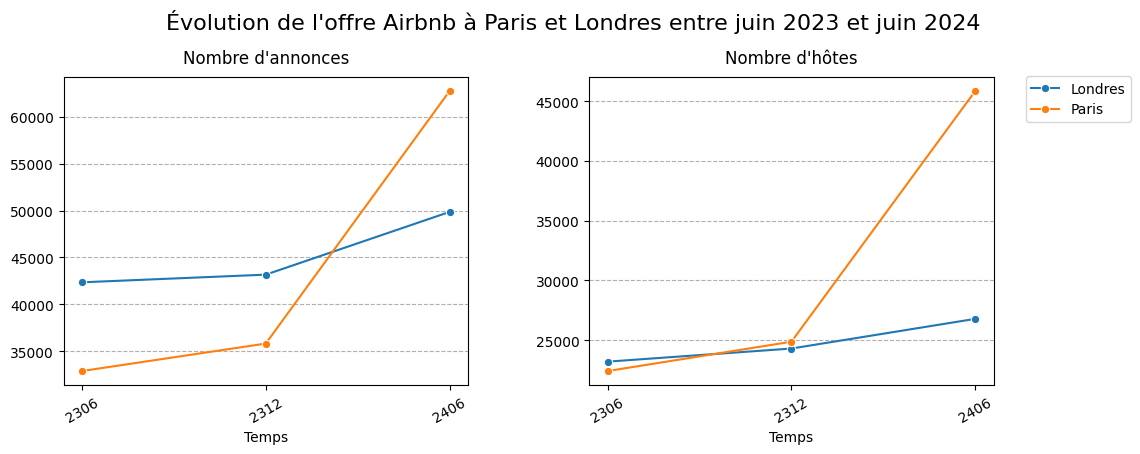

In [5]:
## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(12, 4)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])


df=df_all.copy()
cols=['id', 'host_id']
titles=["Nombre d'annonces", "Nombre d'hôtes"]

for i, col in enumerate(cols):
    # ---supply---
    print(i, col)
    agg=df.groupby(['in_paris','time'])[col].nunique().reset_index(name='count')
    display(agg)
    sns.lineplot(
        data=agg,
        x='time',
        y='count',
        hue='in_paris',
        marker='o',
        ax=axes[i],
        # legend=False
    )
    axes[i].grid(axis='y', linestyle='--')
    axes[i].set_title(titles[i],pad=10)
    axes[i].set_xlabel('Temps')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis="x", rotation=30)

    if axes[i].legend():
        axes[i].get_legend().remove()

fig.suptitle(
        f"Évolution de l'offre Airbnb à Paris et Londres entre juin 2023 et juin 2024",
        fontsize=16,
        y=1.05,
        x=0.55 #在整张图的中心居中
    )

handles, labels=axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    ['Londres', 'Paris'],
    loc="upper right",
    bbox_to_anchor=(1.02,0.9) # legend (x, y)，x>1则在图外, y=0在底线
)
plt.tight_layout(rect=[0, 0.1, 0.9,1])


,in_paris,time,value
0,0,2306,152637.0
1,0,2312,95443.0
2,0,2406,155922.0
3,1,2306,129622.0
4,1,2312,82843.0
5,1,2406,145386.0


,in_paris,time,value
0,0,2306,3.603669
1,0,2312,2.210762
2,0,2406,3.127447
3,1,2306,3.939759
4,1,2312,2.312177
5,1,2406,2.317352


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\2963963420.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.9,1])


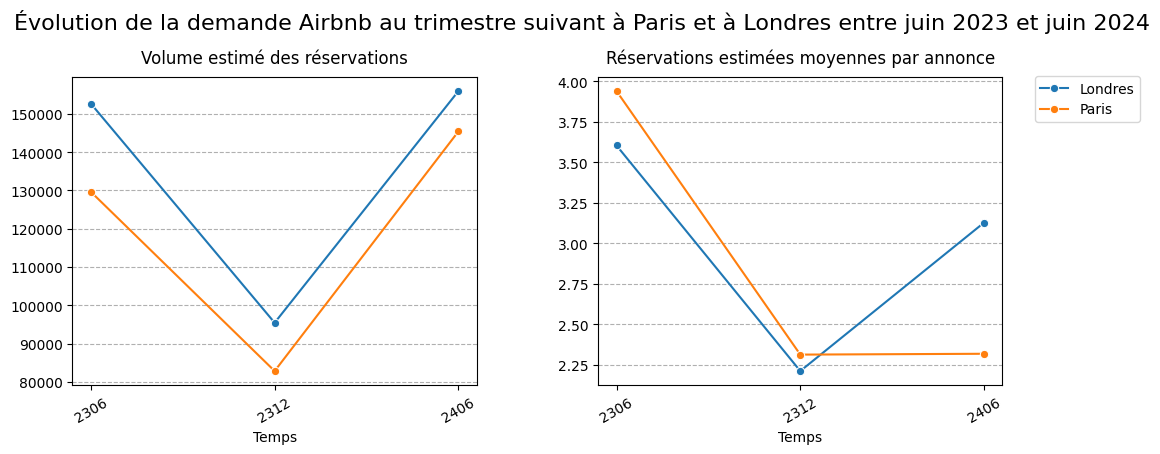

In [6]:
## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(12, 4)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])



df=df_all.copy()


aggs=[]
agg1=df.groupby(['in_paris','time'])["number_of_reviews_nextQ"].sum().reset_index(name='value')# sum
agg2=df.groupby(['in_paris','time'])["number_of_reviews_nextQ"].mean().reset_index(name='value')# mean
aggs.append(agg1)
aggs.append(agg2)
titles=["Volume estimé des réservations", "Réservations estimées moyennes par annonce"]
# Nombre d'avis total du trimestre suivant", Nombre d'avis moyen par annonce


for i, agg in enumerate(aggs):
    display(agg)
    
    # ---demande---
    sns.lineplot(
        data=agg,
        x='time',
        y='value',
        hue='in_paris',
        marker='o',
        ax=axes[i],
        # legend=False
    )
    axes[i].grid(axis='y', linestyle='--')
    axes[i].set_title(titles[i],pad=10)
    axes[i].set_xlabel('Temps')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis="x", rotation=30)

    if axes[i].legend():
        axes[i].get_legend().remove()

fig.suptitle(
        "Évolution de la demande Airbnb au trimestre suivant à Paris et à Londres entre juin 2023 et juin 2024",
        # f"Évolution de l'offre Airbnb à Paris et Londres entre juin 2023 et juin 2024",
        fontsize=16,
        y=1.05,
        x=0.55
    )

handles, labels=axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    ['Londres', 'Paris'],
    loc="upper right",
    bbox_to_anchor=(1.02,0.9) # legend (x, y)，x>1则在图外, y=0在底线
)
plt.tight_layout(rect=[0, 0.1, 0.9,1])


# global

## desc:

### texte:

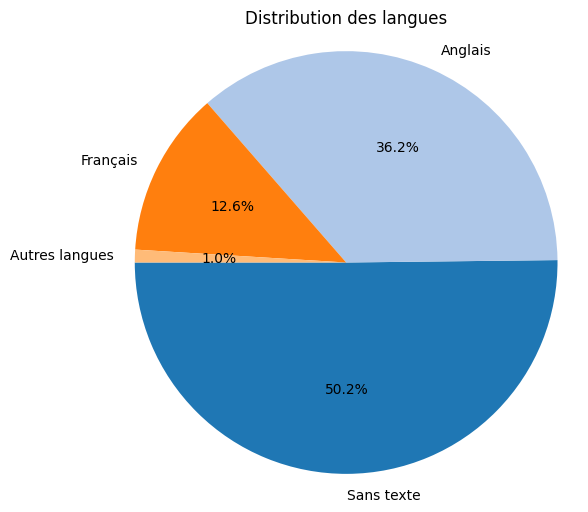

In [7]:
import matplotlib.pyplot as plt

# 数据

mapping = {
    "no_text": "Sans texte",
    "en": "Anglais",
    "fr": "Français",
    "other_langs": "Autres langues"
}

df_all["lang_clean"] = df_all["lang"].map(mapping)


data = (
    df_all["lang_clean"]
    .value_counts(dropna=False, normalize=True)
    .reset_index()
)
data.columns = ["lang", "share"]
colors = plt.cm.tab20.colors[:len(data)]

plt.figure(figsize=(6, 6))
plt.pie(
    data["share"],              # 数值
    labels=data["lang"],        # 标签
    autopct='%1.1f%%',
    colors=colors,
    startangle=180
)
plt.title("Distribution des langues")
plt.axis('equal')
plt.show()


In [8]:
sub=df_all.copy()
sub['has_text'].value_counts(dropna=False, normalize=True)


has_text
0    0.501821
1    0.498179
Name: proportion, dtype: float64

In [9]:

sub[sub['has_text']==1]['text_length'].describe()

count    132940.000000
mean         62.585099
std          70.003960
min           1.000000
25%          20.000000
50%          44.000000
75%          75.000000
max        1040.000000
Name: text_length, dtype: float64

### tactiques

In [10]:
df=df_all.copy()
agg=df.groupby(['in_paris','time'])[tactics_bio+tactics_pic_dummies].mean().reset_index()
agg_long=agg.melt(
    id_vars=['in_paris', 'time'],
    value_vars=tactics_bio+tactics_pic_dummies,
    var_name='variable',
    value_name='mean'
)
agg_long['group']=agg_long.apply(lambda row: f"{'Paris' if row['in_paris']==1 else 'Londres'} {row['time']}", axis=1)

agg_long

,in_paris,time,variable,mean,group
0,0,2306,ouverture,-0.111349,Londres 2306
1,0,2312,ouverture,-0.111726,Londres 2312
2,0,2406,ouverture,-0.113564,Londres 2406
3,1,2306,ouverture,-0.093083,Paris 2306
4,1,2312,ouverture,-0.083193,Paris 2312
5,1,2406,ouverture,-0.088205,Paris 2406
6,0,2306,authenticité,-0.181066,Londres 2306
7,0,2312,authenticité,-0.204839,Londres 2312
8,0,2406,authenticité,-0.216109,Londres 2406
9,1,2306,authenticité,-0.158274,Paris 2306


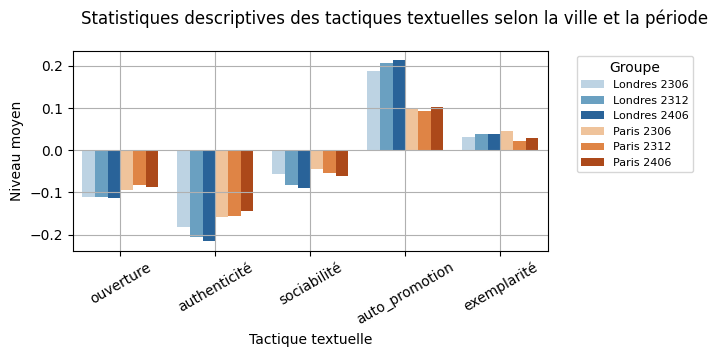

In [11]:


tactics=tactics_bio
df_plot=agg_long[agg_long['variable'].isin(tactics)].copy()
groups=df_plot['group'].unique()

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 3  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)
palette={k: v for k, v in zip (groups, colors)}


# vis
fig, ax=plt.subplots(figsize=(8,4))

sns.barplot(
    data=df_plot,   
    x="variable",
    y="mean",
    hue="group",
    palette=palette,
    order=tactics_bio,#***
    # errorbar="sd"
    ax=ax
)
ax.tick_params(axis="x", rotation=30)
ax.set_ylabel("Niveau moyen")
ax.set_xlabel("Tactique textuelle")
ax.grid()

plt.suptitle("Statistiques descriptives des tactiques textuelles selon la ville et la période",fontsize=12)

handles, labels=ax.get_legend_handles_labels()
plt.legend(handles, labels, title="Groupe", loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout(rect=[0,0.1, 0.9,1])

plt.show()
# 整体而言，paris更注重ouv，authen，socio，london的auto更高，exem两者相似


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\1292629499.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


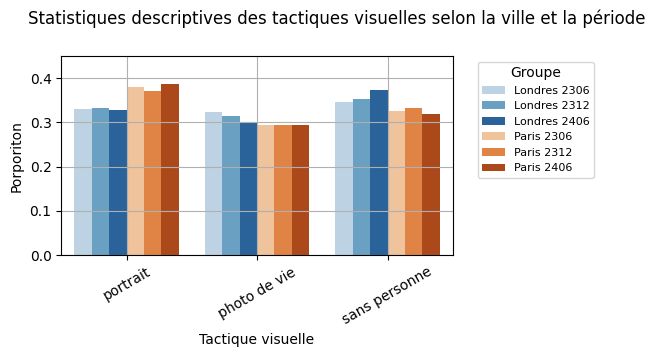

In [12]:
tactics=tactics_pic_dummies
label_map={'is_portrait':"portrait",
           'is_lifestyle':'photo de vie',
           "no_person":"sans personne"}

df_plot=agg_long[agg_long['variable'].isin(tactics)].copy()
groups=df_plot['group'].unique()

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 3  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)
palette={k: v for k, v in zip (groups, colors)}


# vis
fig, ax=plt.subplots(figsize=(7,4))

sns.barplot(
    data=df_plot,   
    x="variable",
    y="mean",
    hue="group",
    palette=palette,
    order=tactics,#***
    # errorbar="sd"
    ax=ax
)

ax.set_ylim(0, 0.45)
ax.set_xticklabels(
    [label_map[x.get_text()] for x in ax.get_xticklabels()],
    rotation=30
)
# ax.set_xticklabels([label_map[x.get_text()] for x in ax.get_xticklabels],rotation=30)
ax.tick_params(axis="x", rotation=30)
ax.set_ylabel("Porporiton")
ax.set_xlabel("Tactique visuelle")
ax.grid()

plt.suptitle("Statistiques descriptives des tactiques visuelles selon la ville et la période",
             fontsize=12,
             y=0.98)

handles, labels=ax.get_legend_handles_labels()

plt.legend(handles, labels, title="Groupe", loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout(rect=[0,0.1, 0.9,1])

plt.show()
# 整体而言，paris更注重ouv，authen，socio，london的auto更高，exem两者相似



## dynamique des did

In [13]:
models=[]
tactics=tactics_bio+tactics_pic_dummies
for var in tactics:
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                    "number_of_reviews_ltm + "
                    "C(host_is_superhost) +"
                    "years_since_host + professional_host + "
                    "host_response_rate +  C(host_response_time)+"
                    "has_text + lang_en + lang_fr + text_length+"
                    "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                    "C(time) + in_paris * C(time)"
            )
    model_tactic=smf.ols(formula, data=df_all).fit()
    models.append(model_tactic)
    # break
# models

In [14]:
def get_event_study_data(model, var):
    params = model.params
    bse = model.bse
    pvalues=model.pvalues
    
    # 提取 interaction terms
    data = pd.DataFrame({
        "coef": params,
        "se": bse,
        'pval':pvalues
    }).reset_index()

    data.columns = ["variable", "coef", "se", "pval"]

    # 只保留 in_paris × time
    data = data[data["variable"].str.contains("in_paris:C\\(time\\)")]    
    
    # 提取时间点
    data["time"] = data["variable"].str.extract(r"T\.(\d+)")

    # 排序
    data = data.sort_values("time")

    # 置信区间
    data["ci_low"] = data["coef"] - 1.96 * data["se"]
    data["ci_high"] = data["coef"] + 1.96 * data["se"]
    
    # baseline（2306 = 0）
    baseline = pd.DataFrame({
        "time": ["2306"],
        "coef": [0],
        "ci_low": [0],
        "ci_high": [0]
    })

    data = pd.concat([baseline, data], ignore_index=True)

    data = data.sort_values("time")
    data['variable']=var
    data['sig']=data['pval'].apply(p_to_sig)        
    # data['label']=data['time']+' '+data['sig']        
    
    return data  

results=[]
for var, model_tactic in zip(tactics, models):
    print(var)
    res=get_event_study_data(model_tactic, var)
    results.append(res)

results_did_evolution=pd.concat(results, axis=0)
display(results_did_evolution)

ouverture
authenticité
sociabilité
auto_promotion
exemplarité
is_portrait
is_lifestyle
no_person


,time,coef,ci_low,ci_high,variable,se,pval,sig
0,2306,0.000000,0.000000,0.000000,ouverture,NaN,NaN,
1,2312,0.005668,-0.006977,0.018313,ouverture,0.006452,3.796275e-01,
2,2406,0.001713,-0.010052,0.013477,ouverture,0.006002,7.753645e-01,
0,2306,0.000000,0.000000,0.000000,authenticité,NaN,NaN,
1,2312,0.029654,0.016556,0.042753,authenticité,0.006683,9.113254e-06,***
2,2406,0.043697,0.031511,0.055884,authenticité,0.006218,2.099537e-12,***
0,2306,0.000000,0.000000,0.000000,sociabilité,NaN,NaN,
1,2312,0.022324,0.008787,0.035861,sociabilité,0.006906,1.228010e-03,**
2,2406,0.034783,0.022189,0.047377,sociabilité,0.006426,6.193342e-08,***
0,2306,0.000000,0.000000,0.000000,auto_promotion,NaN,NaN,


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\2334051034.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


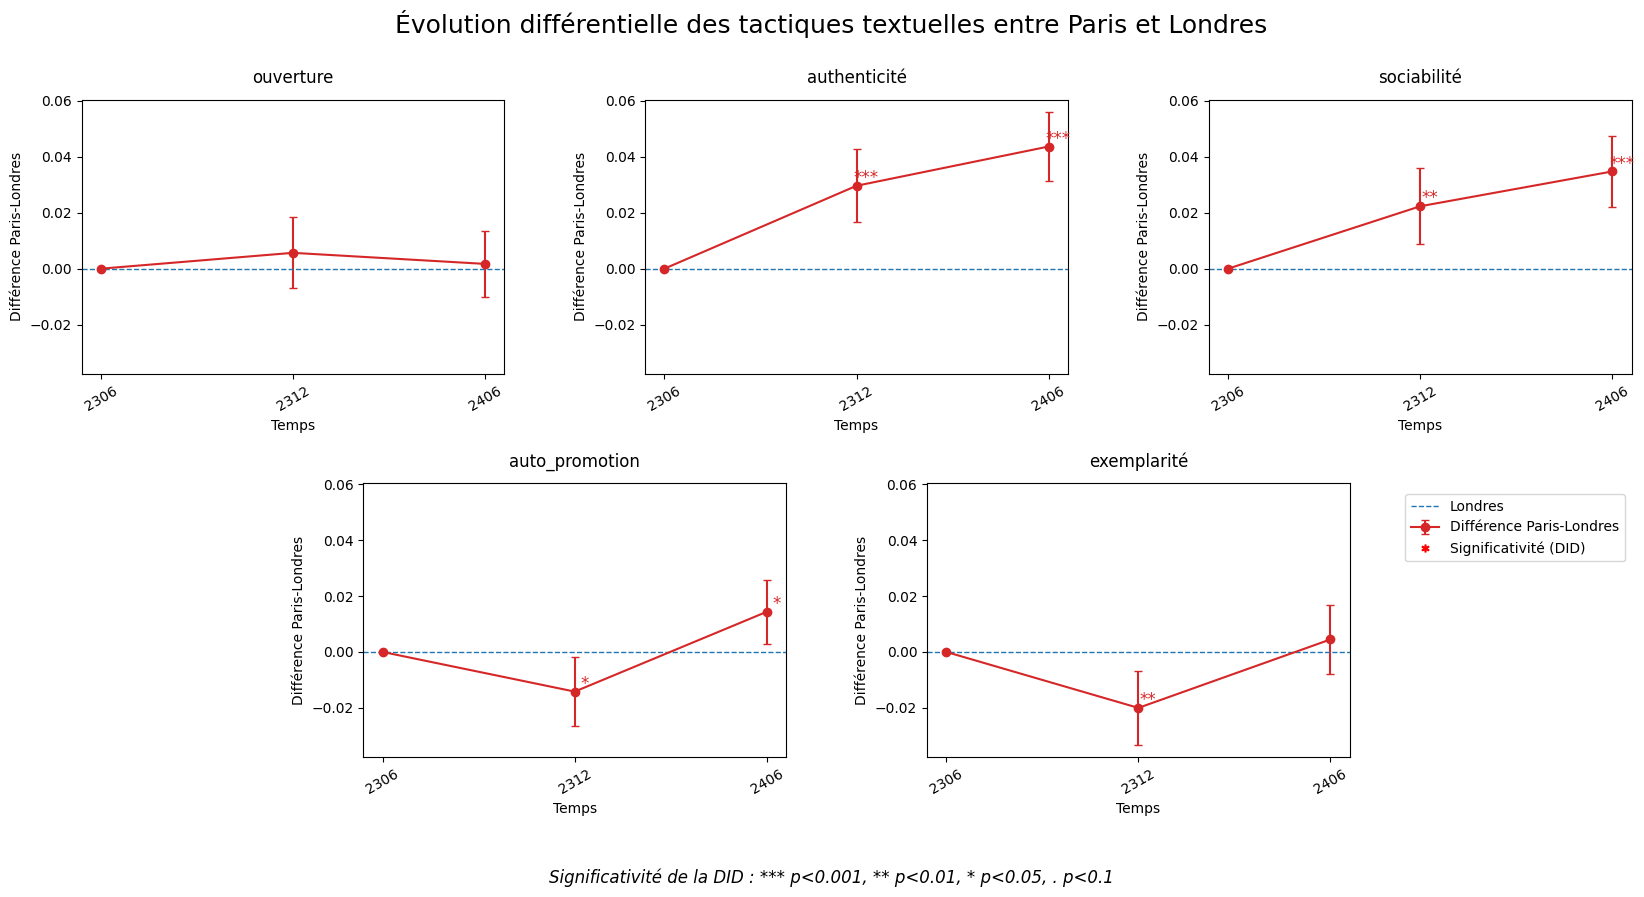

In [15]:
from utils import modeling_did
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_did

# ---layout---
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))# sharey=True
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 4:6], sharey=ax1)
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3], sharey=ax1)
ax5 = fig.add_subplot(gs[1, 3:5], sharey=ax1)
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
# n_to_plot = min(len(tactics), len(axes))


tactics=tactics_bio
df_plot=results_did_evolution.copy()#[results_did_evolution['variable'].isin(tactics)].copy()

for i, var in enumerate(tactics):
    plot_one_did(data=df_plot, axes=axes, i=i, var=var, title=None)
    
# --------------------legend------------------------
fig.suptitle(
        "Évolution différentielle des tactiques textuelles entre Paris et Londres",
        fontsize=18,
        y=0.98 #大标题到子图的距离, 越大越远
    )

from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
# --- add custom legend :sig note ---
handles.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='red', markersize=5,
           label='Significativité (DID)')
)
labels = labels + [
    "Significativité (DID)"
]

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\2595009283.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8,1])


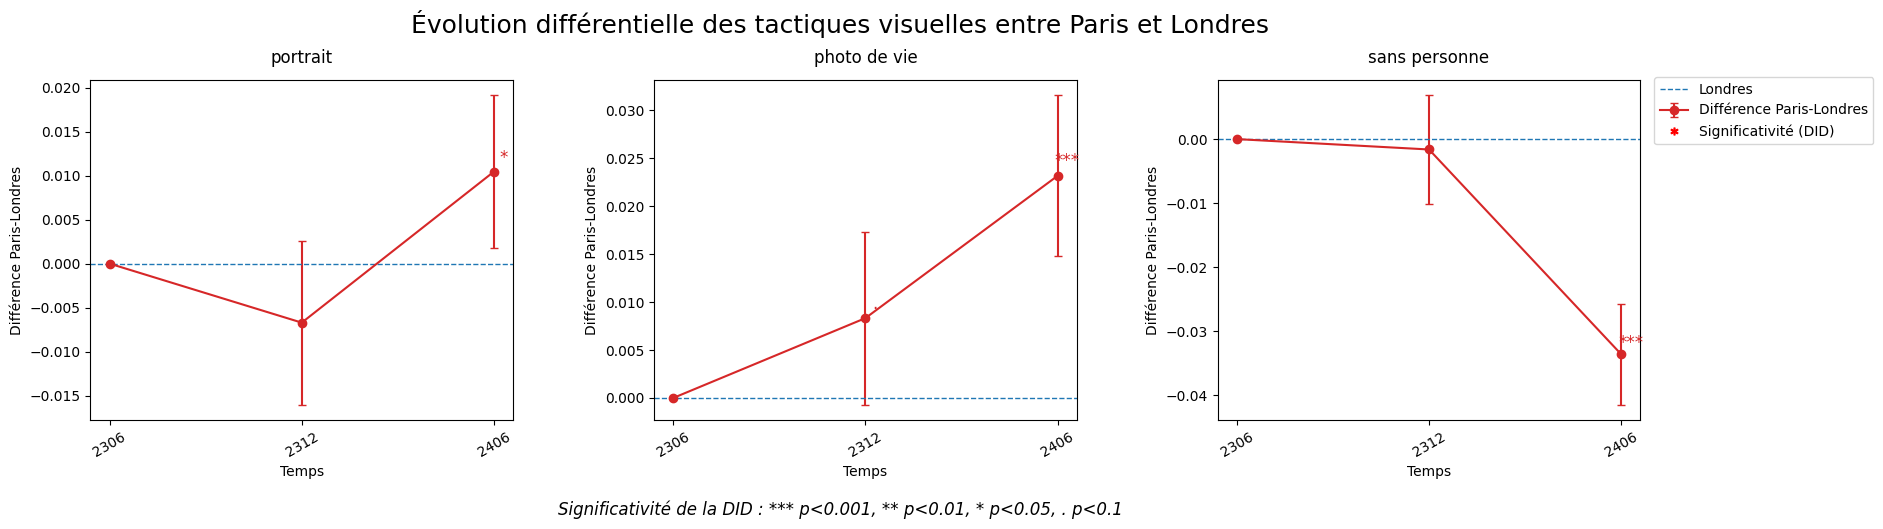

In [16]:
# ---layout---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,5))# sharey=True
gs = gridspec.GridSpec(1, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])


## plot
tactics=tactics_pic_dummies
tactics_pic_labels=['portrait','photo de vie','sans personne']
var_map=dict(zip(tactics_pic_dummies,tactics_pic_labels))

df_plot=results_did_evolution.copy()

for i, var in enumerate(tactics):
    plot_one_did(data=df_plot, axes=axes, i=i, var=var, title=var_map.get(var))
    
      
# layout 3facets:
fig.suptitle(
        "Évolution différentielle des tactiques visuelles entre Paris et Londres",
        fontsize=18,
        y=1.02
    )

# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
# --- add custom legend :sig note ---
handles.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='red', markersize=5,
           label='Significativité (DID)')
)
labels = labels + [
    "Significativité (DID)"
]

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.02,0.9) # legend (x, y)，x>1则在图外, y=0在底线
)
plt.figtext(
    0.5, 0.01,
    "Significativité de la DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 0.8,1])
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()
## ddd只能说明paris相对于london的变化，但是不知道是paris提升还是london下降，比如lifestyle中就是paris不变，但是london大幅下降了

# 总体上por上升，vie不变，sans下降！

## variation de did entre 2312 et 2406


In [17]:
specs=[
    """    
    in_paris:C(time)[T.2406]
    -in_paris:C(time)[T.2312]  
    """
]

results=[]
var_map={
    # 'auto_promotion':"auto-promotion",
    'is_portrait':"portrait",
    "is_lifestyle":'photo de vie',
    "no_person":'sans personne'
}

tactics=tactics_bio+tactics_pic_dummies
for var, model_tactic in zip(tactics, models):
    for i, term in enumerate(specs):
        test = model_tactic.t_test(term)
        sig=p_to_sig(test.pvalue)
        res= pd.DataFrame({
            'variable':var,
            "coef": test.effect[0],
            "se": test.sd[0],
            "pval": test.pvalue,
            "sig":sig,
            "ci_low": test.conf_int()[0][0],
            "ci_high": test.conf_int()[0][1],
            'label':f"{var_map.get(var,'') if var in var_map else var}"
        })
        results.append(res)

results_did_diff=pd.concat(results, axis=0)
display(results_did_diff)

,variable,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,-0.003955,0.005895,5.022069e-01,,-0.015509,0.007598,ouverture
0,authenticité,0.014043,0.006106,2.145399e-02,*,0.002076,0.026011,authenticité
0,sociabilité,0.012459,0.006310,4.832976e-02,*,0.000091,0.024827,sociabilité
0,auto_promotion,0.028564,0.005753,6.870991e-07,***,0.017288,0.039839,auto_promotion
0,exemplarité,0.024492,0.006112,6.149051e-05,***,0.012512,0.036471,exemplarité
0,is_portrait,0.017154,0.004337,7.652006e-05,***,0.008653,0.025654,portrait
0,is_lifestyle,0.014838,0.004201,4.121373e-04,***,0.006605,0.023072,photo de vie
0,no_person,-0.031992,0.003934,4.268024e-16,***,-0.039703,-0.024280,sans personne


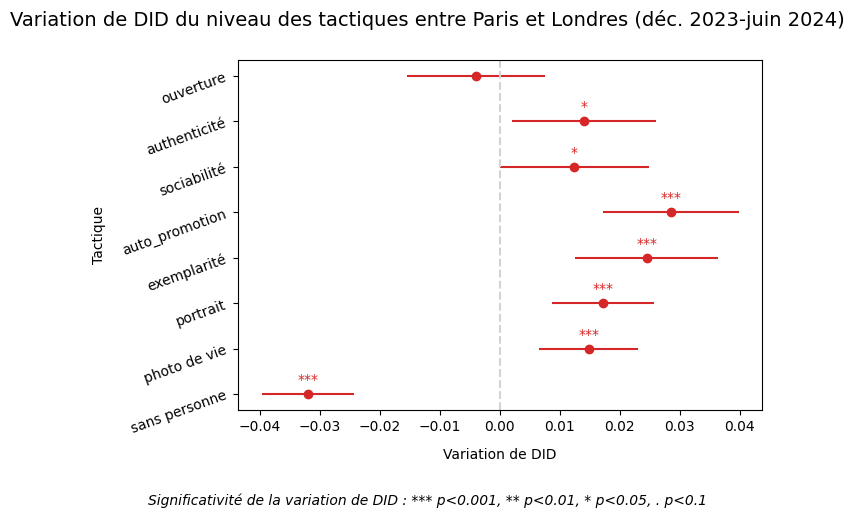

In [18]:
fig, ax=plt.subplots(figsize=(7,5))
change_colors='tab:red'
sub=results_did_diff.copy()

tactics=tactics_bio+['portrait','photo de vie','sans personne']
order=tactics[::-1]
sub=sub.set_index('label').loc[order].reset_index()


# ---plot---
ax.errorbar(
    x=sub["coef"],
    y=sub["label"],
    # y=y,
    xerr=[sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]],
    fmt='o', 
    color=change_colors,
    # linestyle='-' if new==1 else '--'
)
# ---sig---
for _, row in sub.iterrows():
    ax.annotate(
        row["sig"],
        xy=(row["coef"], row["label"]),
        xytext=(0, 10),         
        textcoords='offset points',
        ha='center',
        va='center',
        fontsize=10,
        color=change_colors
)    
        
ax.axvline(0, linestyle='--', color="lightgray", label="Changement de Londres")    
ax.set_xlabel(f"Variation de DID", labelpad=10)
ax.set_ylabel('Tactique', labelpad=10)
ax.tick_params(axis='y', rotation=20)
# ax.set_title()

fig.suptitle(
    "Variation de DID du niveau des tactiques entre Paris et Londres (déc. 2023-juin 2024)",
    # "Evolution de l'écart des niveaux de tactiques entre Paris et Londres (déc. 2023 - juin 2024)", 
    fontsize=14,
    y=1
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la variation de DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

## save as latex

In [19]:
from statsmodels.iolib.summary2 import summary_col
table = summary_col(models, stars=True)
print(table.as_latex())

\begin{table}
\caption{}
\label{}
\begin{center}
\begin{tabular}{lllllllll}
\hline
                                              & ouverture  & authenticité & sociabilité & auto\_promotion & exemplarité & is\_portrait & is\_lifestyle & no\_person  \\
\hline
Intercept                                     & -0.2837*** & -0.3503***   & -0.1511***  & 0.2421***       & 0.0991***   & 0.0793***    & 0.0780***     & 0.8427***   \\
                                              & (0.0185)   & (0.0192)     & (0.0198)    & (0.0181)        & (0.0192)    & (0.0136)     & (0.0132)      & (0.0124)    \\
C(host\_identity\_verified)[T.t]              & 0.0257***  & 0.0935***    & 0.0461***   & -0.0500***      & 0.0290***   & 0.0048       & 0.0206***     & -0.0254***  \\
                                              & (0.0049)   & (0.0051)     & (0.0053)    & (0.0048)        & (0.0051)    & (0.0036)     & (0.0035)      & (0.0033)    \\
C(host\_is\_superhost)[T.t]                   & 0.0597***  & 0.1000***

In [20]:
import pandas as pd

index_vars = [
    "in_paris",
    "C(time)[T.2312]",
    "C(time)[T.2406]",
    "in_paris:C(time)[T.2312]",
    "in_paris:C(time)[T.2406]",
    "R-squared",
    "Adj. R-squared"
]

table = pd.DataFrame(index=index_vars)
for var, m in zip(tactics, models):
    var_map={
        # 'auto_promotion':"auto-promotion",
        'is_portrait':"portrait",
        "is_lifestyle":'photo de vie',
        "no_person":'sans personne'
    }
    var=var_map.get(var,'') if var in var_map.keys() else var
    print(var)
    coef = m.params

    table[var] = [
    f"{coef.get('in_paris', None):.3f}{p_to_sig(m.pvalues.get('in_paris', 1))}",

    f"{coef.get('C(time)[T.2312]', None):.3f}{p_to_sig(m.pvalues.get('C(time)[T.2312]', 1))}",

    f"{coef.get('C(time)[T.2406]', None):.3f}{p_to_sig(m.pvalues.get('C(time)[T.2406]', 1))}",

    f"{coef.get('in_paris:C(time)[T.2312]', None):.3f}{p_to_sig(m.pvalues.get('in_paris:C(time)[T.2312]', 1))}",

    f"{coef.get('in_paris:C(time)[T.2406]', None):.3f}{p_to_sig(m.pvalues.get('in_paris:C(time)[T.2406]', 1))}",

    m.rsquared,
    m.rsquared_adj
]
print("\n",table.to_latex(float_format="%.3f"))



# # ---save---
# path_tex=r"..\latexMM2\memoire-M2_Ye-LIU\tables_2/model_tactic_keyvars.tex"

# latex_table = table.to_latex(
#     index=True,
#     escape=True,   # 保留latex符号和星号
#     float_format="%.3f"
# )
# with open(
#     path_tex, 
#     "w",
#     encoding="utf-8"
# ) as f:
#     f.write(latex_table)


ouverture
authenticité
sociabilité
auto_promotion
exemplarité
portrait
photo de vie
sans personne

 \begin{tabular}{lllllllll}
\toprule
 & ouverture & authenticité & sociabilité & auto_promotion & exemplarité & portrait & photo de vie & sans personne \\
\midrule
in_paris & 0.087*** & -0.117*** & -0.007 & -0.037*** & -0.052*** & 0.007* & -0.056*** & 0.049*** \\
C(time)[T.2312] & 0.004 & -0.023*** & -0.028*** & 0.025*** & 0.013** & 0.004 & 0.002 & -0.006. \\
C(time)[T.2406] & 0.004 & -0.033*** & -0.038*** & 0.028*** & 0.004 & 0.004 & -0.011*** & 0.007* \\
in_paris:C(time)[T.2312] & 0.006 & 0.030*** & 0.022** & -0.014* & -0.020** & -0.007 & 0.008. & -0.002 \\
in_paris:C(time)[T.2406] & 0.002 & 0.044*** & 0.035*** & 0.014* & 0.004 & 0.010* & 0.023*** & -0.034*** \\
R-squared & 0.080 & 0.169 & 0.032 & 0.267 & 0.075 & 0.067 & 0.052 & 0.219 \\
Adj. R-squared & 0.080 & 0.169 & 0.032 & 0.267 & 0.075 & 0.066 & 0.052 & 0.219 \\
\bottomrule
\end{tabular}



In [21]:
controls = [
    "C(host_identity_verified)[T.t]",
    "review_scores_rating",
    "has_rating",
    "number_of_reviews_ltm",

    "years_since_host",
    "C(host_is_superhost)[T.t]",
    "professional_host",
    
    "host_response_rate",
    "C(host_response_time)[T.no_response_time]",
    "C(host_response_time)[T.within a day]",
    "C(host_response_time)[T.within a few hours]",
    "C(host_response_time)[T.within an hour]",
    # "C(host_response_time)",
    
    "has_text",
    "lang_en",
    "lang_fr",
    "text_length",

    "price",
    "availability_90",
    # "C(room_type)",
    "C(room_type)[T.Hotel room]",
    "C(room_type)[T.Private room]",
    "C(room_type)[T.Shared room]",
    # "C(instant_bookable)",
    "C(instant_bookable)[T.t]"
]

vars = controls #all_vars + controls + ["R-squared", "Adj. R-squared"]

df_large = pd.DataFrame(index=index)

def fmt(coef, p):
    if coef is None:
        return None
    return f"{coef:.3f}{p_to_sig(p)}"
for var, m in zip(tactics, models):
    var_map={
            # 'auto_promotion':"auto-promotion",
            'is_portrait':"portrait",
            "is_lifestyle":'photo de vie',
            "no_person":'sans personne'
        }
    var=var_map.get(var,'') if var in var_map.keys() else var
    print(var)

    col = {}
    for v in index:#*
        col[v] = fmt(
            m.params.get(v, None),
            m.pvalues.get(v, 1)
        )

    col["R-squared"] = m.rsquared
    col["Adj. R-squared"] = m.rsquared_adj

    df_large[var] = pd.Series(col)

# tactics_pic_labels=['portrait','photo de vie','sans personne']

# df_large.columns=tactics_bio+tactics_pic_labels
display(df_large)


# # # ---save---
# path_tex=r"..\latexMM2\memoire-M2_Ye-LIU\tables_2/model_tactic_ctrlvars.tex"

# latex_table = df_large.to_latex(
#     index=True,
#     escape=True,   # 保留latex符号和星号
#     float_format="%.3f"
# )
# with open(
#     path_tex, 
#     "w",
#     encoding="utf-8"
# ) as f:
#     f.write(latex_table)


NameError: name 'index' is not defined

## graphique en niveau:

In [22]:
## real+cf effet 
def get_cf_data(df, model, var):
    """
    不改变时间，不改变地点，仅减去jo（交互项之差）
    """    
    df["y_hat"] = model.predict(df)
    
    term = ('''
        in_paris:C(time)[T.2406]
        - in_paris:C(time)[T.2312]
    '''
    )

    # #jo shock，没有2406-2312则是paris shock
    # #将2312作为了变化的基准，所以不用考虑2306-2312的不平行
    
    test = model.t_test(term)
    adjustment=test.effect[0]
    pval=test.pvalue
    sig=p_to_sig(pval)

    print(f'ddd of {var}: {adjustment} {sig}')
    df["y_cf"] = df["y_hat"]

    df.loc[
        (df["in_paris"]==1) & (df["time"]=="2406"),
        "y_cf"
    ] -= adjustment #==去掉2406交互项，再加一次2312交互项
    
    agg=df.groupby(['in_paris','time'])[['y_hat']].mean().reset_index()
    agg['variable']=var
    
    var_map={
        'is_portrait':"portrait",
        "is_lifestyle":'photo de vie',
        "no_person":'sans personne'
    }
    agg['label']=agg['variable'].apply(lambda x: var_map.get(x,'') if x in var_map.keys() else x)
    
    # # +pval +sig
    agg["pval"] = np.nan 
    agg["sig"] = np.nan 
    agg.loc[
        (agg['in_paris']==1)&(agg['time']=="2406"),
        'var_did'
            ]=adjustment
    agg.loc[
        (agg['in_paris']==1)&(agg['time']=="2406"),
        'pval'
            ]=pval
    agg.loc[
        (agg['in_paris']==1)&(agg['time']=="2406"),
        'sig'
            ]=sig 
    return agg 

aggs=[]
tactics=tactics_bio+tactics_pic_dummies
for var, model_tactic in zip(tactics, models):
    agg=get_cf_data(df=df_all, model=model_tactic, var=var)
    aggs.append(agg)
    # break
cf_data=pd.concat(aggs,axis=0)
cf_data

ddd of ouverture: -0.003955410205441894 


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\550550397.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  agg.loc[


ddd of authenticité: 0.014043224391017566 *


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\550550397.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '*' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  agg.loc[


ddd of sociabilité: 0.012459292106811095 *


...

ddd of is_lifestyle: 0.014838140513398013 ***


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\550550397.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '***' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  agg.loc[


ddd of no_person: -0.03199182415614951 ***


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\550550397.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '***' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  agg.loc[


,in_paris,time,y_hat,variable,label,pval,sig,var_did
0,0,2306,-0.111349,ouverture,ouverture,NaN,NaN,NaN
1,0,2312,-0.111726,ouverture,ouverture,NaN,NaN,NaN
2,0,2406,-0.113564,ouverture,ouverture,NaN,NaN,NaN
3,1,2306,-0.093083,ouverture,ouverture,NaN,NaN,NaN
4,1,2312,-0.083193,ouverture,ouverture,NaN,NaN,NaN
5,1,2406,-0.088205,ouverture,ouverture,5.022069e-01,,-0.003955
0,0,2306,-0.181066,authenticité,authenticité,NaN,NaN,NaN
1,0,2312,-0.204839,authenticité,authenticité,NaN,NaN,NaN
2,0,2406,-0.216109,authenticité,authenticité,NaN,NaN,NaN
3,1,2306,-0.158274,authenticité,authenticité,NaN,NaN,NaN


In [23]:
## check
agg=df_all.groupby(['in_paris','time'])[tactics_bio+tactics_pic_dummies].mean().reset_index()
agg_long=agg.melt(
    id_vars=['in_paris','time'],
    value_vars=tactics_bio+tactics_pic_dummies,
    var_name='variable',
    value_name='mean'
)
agg_long[agg_long['variable']==var]

,in_paris,time,variable,mean
42,0,2306,no_person,0.346633
43,0,2312,no_person,0.353331
44,0,2406,no_person,0.373375
45,1,2306,no_person,0.325887
46,1,2312,no_person,0.333110
47,1,2406,no_person,0.319216


['ouverture' 'authenticité' 'sociabilité' 'auto_promotion' 'exemplarité']


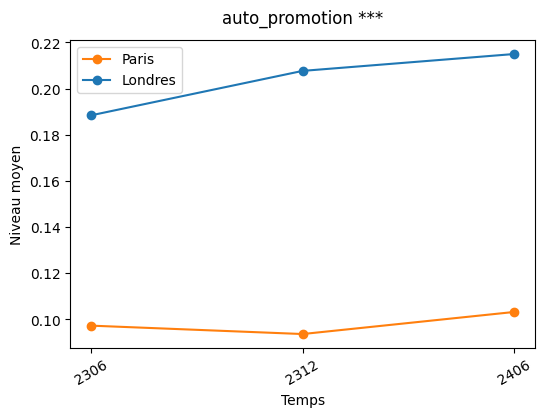

In [24]:
def plot_one_cf(cf_data, axes=None, i=0,  var="authenticité", title=None, ylabel=None, cf=False):
    if not axes:
        fig, ax=plt.subplots(figsize=(6,4))
    else :
        ax=axes[i]

    sub=cf_data[cf_data['label']==var]
    # display(sub)
    
    x=list(range(len(sub['time'].unique())))
    # print("axis x :", x)
    
    ## plt
    paris = sub[sub["in_paris"] == 1]    
    # ---paris obs---
    ax.plot(
        x,
        # paris["time"],#.map(time_map),        
        paris["y_hat"],
        marker="o",
        label="Paris",
        # label="Observé (Paris)",
        color='tab:orange'
    )    
    
    if cf==True:
        # ---paris cf---
        ax.plot(
            x,
            # paris["time"],#.map(time_map),
            paris["y_cf"],
            marker="o",
            linestyle="--",
            label="Contrefactuel(Paris)",
            color='tab:orange'
        )
        # + sig
        ddd_sig=sub[(sub['in_paris']==1)&(sub['time']=="2406")]['sig'].iloc[0]
        xi,yi, sig=2, paris[paris["time"]=="2406"]['y_cf'].iloc[0],ddd_sig
        ax.text(xi, yi + 0.002, sig, ha='center', 
            color='tab:orange', fontsize=12)
    
    
    # ---london obs---
    control = sub[sub["in_paris"] == 0]
    ax.plot(
        control["time"],#.map(time_map),
        control["y_hat"],
        marker="o",
        # alpha=0.4,
        label="Londres",
        # label="Observé (Londres)",
        color='tab:blue'
    )
    
    ax.set_xticks(x)
    ax.set_xticklabels(sub['time'].unique())
    ax.tick_params(axis='x', rotation=30)
    
    ylabel="Niveau moyen" if ylabel is None else ylabel
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Temps")

    title=var if title==None else title
    ddd_sig=sub[(sub['in_paris']==1)&(sub['time']=="2406")]['sig'].iloc[0]

    ax.set_title(f"{title} {ddd_sig}", pad=12)
    if not axes:
        ax.legend(fontsize=10)
        
    return 


df_plot=cf_data[cf_data['variable'].isin(tactics_bio)]
print(df_plot.variable.unique())
var='auto_promotion'

plot_one_cf(cf_data=df_plot, axes=None, i=0,  var=var, title=None, ylabel=None)

# plot_one_cf(agg_data, axes=None, i=0,  var=var, ddd_data=ddd_data, title=None, ylabel=None)


tactics:  ['ouverture' 'authenticité' 'sociabilité' 'auto_promotion' 'exemplarité']


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\1286187925.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.88,1])


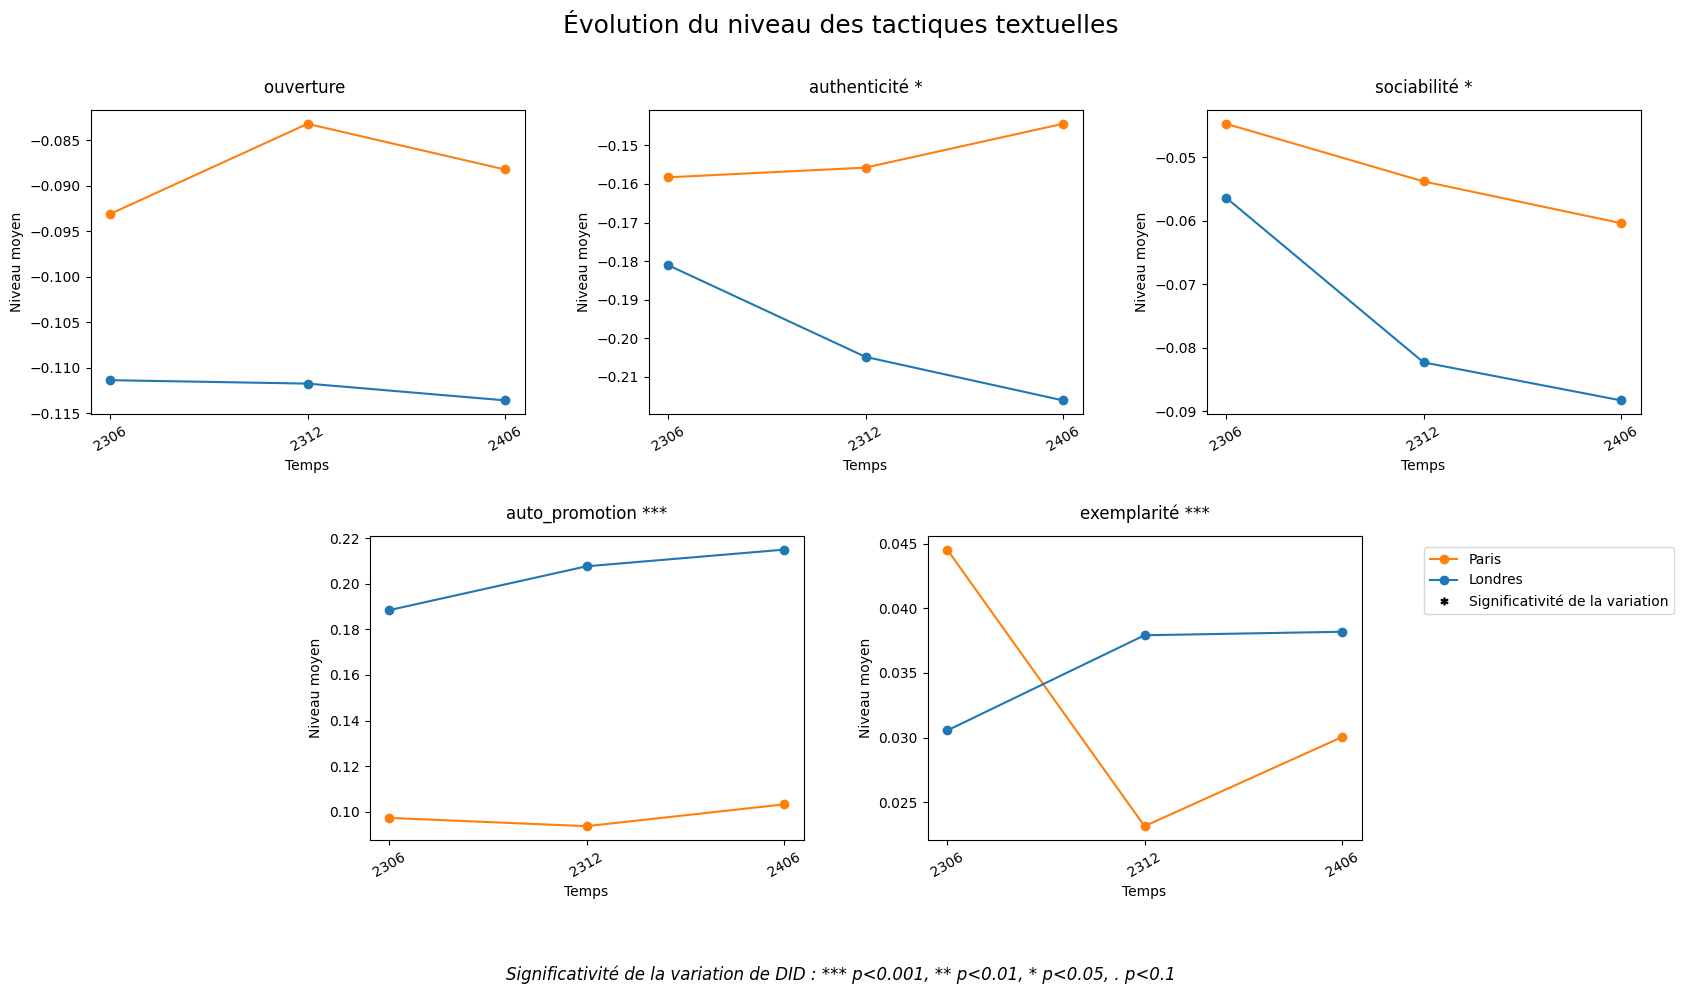

In [25]:

# ---layout---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,10))# sharey=True
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=0.8)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
# n_to_plot = min(len(tactics), len(axes))


## plot:
tactics=tactics_bio
df_plot=cf_data[cf_data['label'].isin(tactics)].copy()
print('tactics: ',df_plot.variable.unique())

for i, var in enumerate(tactics):
    plot_one_cf(cf_data=df_plot, axes=axes, i=i,  var=var, title=None, ylabel=None)
    

# layout:
fig.suptitle(
        "Évolution du niveau des tactiques textuelles",
        fontsize=18,
        y=0.98
    )

# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
# --- add custom legend :sig note ---
handles.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='black', markersize=5,
           label='Significativité de la variation')
)
labels = labels + [
    "Significativité de la variation"
]

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.92,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la variation de DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 0.88,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()

# authen，auto，exem上升，ouv不显著变化，socio下降
# 但是jo都有提升效果！


tactics:  ['portrait' 'photo de vie' 'sans personne']


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\1052372723.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8,1])


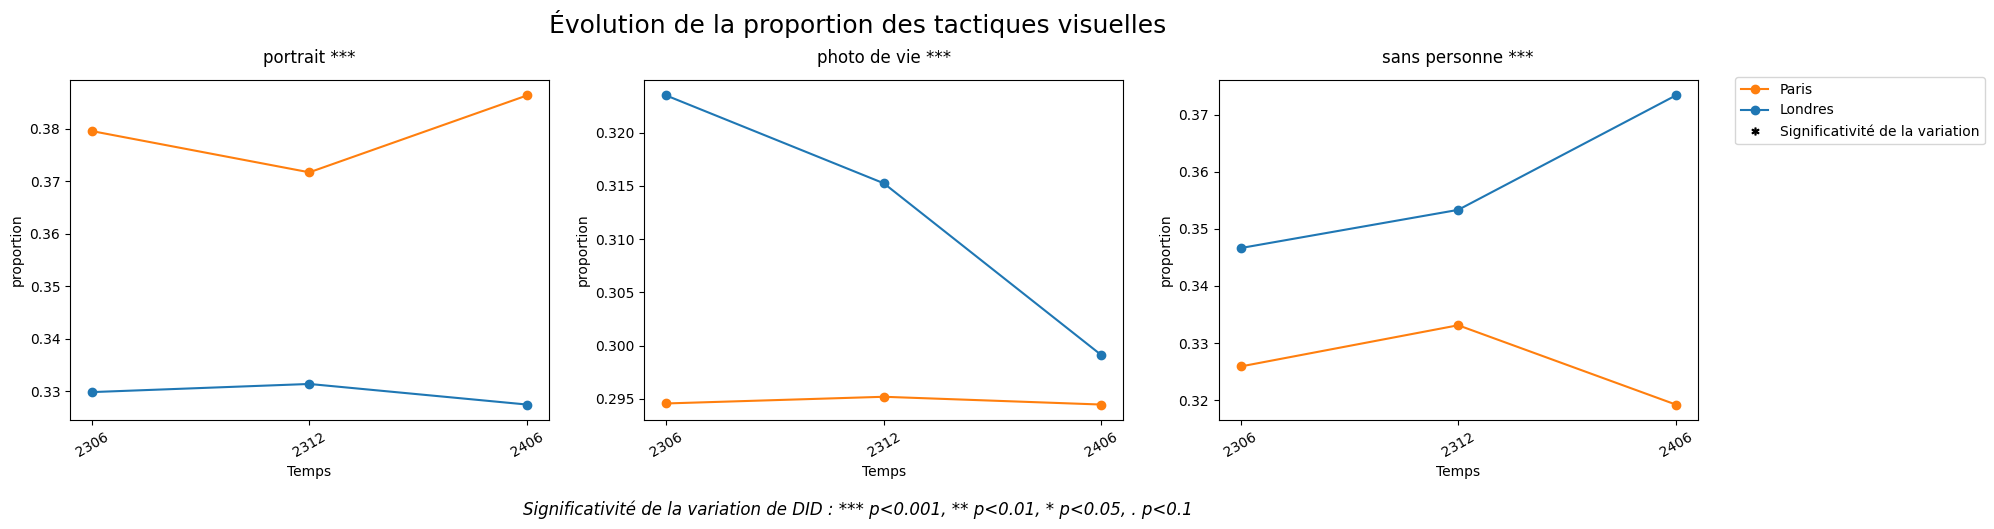

In [26]:

tactics_pic_labels=['portrait','photo de vie','sans personne']
var_map=dict(zip(tactics_pic_dummies,tactics_pic_labels))


# ---layout---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(21,5))# sharey=True
gs = gridspec.GridSpec(1, 6, figure=fig, hspace=0.4, wspace=0.5)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])


## plot:
df_plot=cf_data[cf_data['label'].isin(tactics_pic_labels)].copy() #**
print('tactics: ',df_plot.label.unique())

# title_map={
#     'is_portrait':'Portrait',
#     'is_lifestyle':'Photo de vie',
#     "no_person":"Sans personne"
# }

for i, var in enumerate(tactics_pic_labels):#**
    plot_one_cf(cf_data=df_plot, axes=axes, i=i,  var=var, ylabel='proportion')
      
# layout 3facets:
fig.suptitle(
        "Évolution de la proportion des tactiques visuelles",
        fontsize=18,
        y=1.02
    )

# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
# --- add custom legend :sig note ---
handles.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='black', markersize=5,
           label='Significativité de la variation')
)
labels = labels + [
    "Significativité de la variation"
]

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.04,0.9) # legend (x, y)，x>1则在图外, y=0在底线
)
plt.figtext(
    0.5, 0.01,
    "Significativité de la variation de DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 0.8,1])
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()
## ddd只能说明paris相对于london的变化，但是不知道是paris提升还是london下降，比如lifestyle中就是paris不变，但是london大幅下降了

# 总体上por上升，vie不变，sans下降！

## bilan de mécanismes
tactique| host_type | Δ london(2406-2312) | Δ paris(2406-2312)  | variation did | sig | mécanisme


In [27]:
cf_data

,in_paris,time,y_hat,variable,label,pval,sig,var_did
0,0,2306,-0.111349,ouverture,ouverture,NaN,NaN,NaN
1,0,2312,-0.111726,ouverture,ouverture,NaN,NaN,NaN
2,0,2406,-0.113564,ouverture,ouverture,NaN,NaN,NaN
3,1,2306,-0.093083,ouverture,ouverture,NaN,NaN,NaN
4,1,2312,-0.083193,ouverture,ouverture,NaN,NaN,NaN
5,1,2406,-0.088205,ouverture,ouverture,5.022069e-01,,-0.003955
0,0,2306,-0.181066,authenticité,authenticité,NaN,NaN,NaN
1,0,2312,-0.204839,authenticité,authenticité,NaN,NaN,NaN
2,0,2406,-0.216109,authenticité,authenticité,NaN,NaN,NaN
3,1,2306,-0.158274,authenticité,authenticité,NaN,NaN,NaN


In [28]:
df=cf_data.copy()
df_delta = df[df["time"].isin(["2312", "2406"])].copy()

df_delta = df_delta.pivot_table(
    index=["label", "in_paris"],
    columns="time",
    values="y_hat"
).reset_index()

##--- delta niv---
df_delta["delta"] = df_delta["2406"] - df_delta["2312"]
paris = df_delta[df_delta["in_paris"] == 1].set_index("label")["delta"]
london = df_delta[df_delta["in_paris"] == 0].set_index("label")["delta"]
table = pd.DataFrame({
    "london_delta": london,
    "paris_delta": paris
}).dropna().reset_index()
# display(table)


# ---var did---
df_did = df[(df['in_paris']==1) & (df['time']=="2406")][['label','var_did','sig']]
table=table.merge(df_did[['label','var_did',"sig"]], on="label", how='left')
table['var_did']=table['var_did'].round(4)
table



# ---mécanisme---
def classify_mechanism(paris_delta, london_delta, var_did, sig):
    if pd.isna(sig) or sig == "":
        return "-"
    if paris_delta * london_delta < 0:    #sens opposé
        if var_did > 0: # paris augmente + london descend 
            return "divergence positive"
        else : # paris descend + london augmente
             return "divergence négative"  
          
    else:# même sens 
        # did positif:
        if var_did > 0 :
            if paris_delta > 0 : # paris augmente plus rapidement
                return "accélération relative"# postive
            else :# paris descend plus lentement
                return 'atténuation relative'
        # did négatif
        else :# var_did < 0
            if paris_delta > 0 :# paris augmente plus lentement
                return 'atténuation relative'
            else :# # paris descend plus rapidement
                return "accélération relative"#négative

table["mecanisme"] = table.apply(
    lambda x: classify_mechanism(x.paris_delta, x.london_delta, x.var_did, x.sig),
    axis=1
)

order = [
    'ouverture',
    'authenticité',
    'sociabilité',
    'auto_promotion',
    'exemplarité',
    'portrait',
    'photo de vie',
    'sans personne'
]

table['label'] = pd.Categorical(table['label'], categories=order, ordered=True)
table = table.sort_values('label')
bilan=table.copy()
display(bilan)


bilan.columns=['Tactique',"Δ Londres",'Δ Paris', "Variation de DID","Sig.","Mécanisme"]
# bilan

,label,london_delta,paris_delta,var_did,sig,mecanisme
3,ouverture,-0.001838,-0.005012,-0.0040,,-
0,authenticité,-0.011269,0.011353,0.0140,*,divergence positive
7,sociabilité,-0.005974,-0.006560,0.0125,*,atténuation relative
1,auto_promotion,0.007301,0.009555,0.0286,***,accélération relative
2,exemplarité,0.000270,0.006888,0.0245,***,accélération relative
5,portrait,-0.003915,0.014623,0.0172,***,divergence positive
4,photo de vie,-0.016129,-0.000729,0.0148,***,atténuation relative
6,sans personne,0.020044,-0.013894,-0.0320,***,divergence négative


In [29]:
# path_tex=r"..\latexMM2\memoire-M2_Ye-LIU\tables_2/bilan_mecanisme.tex"

# latex_table = bilan.to_latex(
#     index=False,
#     escape=True,   # 保留latex符号和星号
#     float_format="%.4f"
# )

# with open(
#     path_tex, 
#     "w",
#     encoding="utf-8"
# ) as f:
#     f.write(latex_table)

# hétérogénéité : nouveaux entrants vs hôtes établis

## desc hetero

### variables de contrôle

In [30]:
from utils import preprocess_listings
from utils.preprocess_listings import group_mean_table_ttest
df=df_all[df_all['time']!="2306"].copy()

# clean vars:
df['host_is_superhost']=df['host_is_superhost'].apply(lambda x : 1 if x=="t" else 0)
df['instant_bookable']=df['instant_bookable'].apply(lambda x : 1 if x=="t" else 0)
df['host_identity_verified']=df['host_identity_verified'].apply(lambda x : 1 if x=="t" else 0)
df['host_has_profile_pic']=df['host_has_profile_pic'].apply(lambda x : 1 if x=="t" else 0)

cols_to_check=[
    'booking_rate_l90d',
    
    "host_identity_verified","review_scores_rating", "has_rating", 
    "number_of_reviews_ltm","years_since_host", "host_is_superhost", 'professional_host', 
    "host_response_rate",

    'has_text',"text_length",
    "host_has_profile_pic",
    "price","availability_90", "instant_bookable",
]
compa_ctrl_hetero=group_mean_table_ttest(df, cols_to_check, group_col='is_new_host',
                           save=False, output_folder="mod_results", filename_noext=None)
compa_ctrl_hetero

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :1 vs 0
[INFO] ttest on 191595 lines.

[CHECK] ttest take ONLY numeric cols! 



is_new_host,1,0,ttest_p,significance
proportion,0.325384,0.674616,NaN,NaN
booking_rate_l90d,0.091706,0.091241,0.614776,
host_identity_verified,0.912194,0.944141,0.0,***
review_scores_rating,4.803451,4.724877,0.0,***
has_rating,0.58131,0.833103,0.0,***
number_of_reviews_ltm,4.185044,10.108199,0.0,***
years_since_host,6.209618,7.042189,0.0,***
host_is_superhost,0.113711,0.279259,0.0,***
professional_host,0.219082,0.615723,0.0,***
host_response_rate,0.697621,0.815245,0.0,***


### nombres d'annonces + d'hôtes 

In [31]:
agg = (
    df_all
    .groupby(["time", "in_paris", "is_new_host"])
    .size()
    .reset_index(name="count")
)
display(agg)

pivot = agg.pivot_table(
    index=["time", "in_paris"],
    columns="is_new_host",
    values="count",
    fill_value=0
).reset_index()

pivot.columns = ["time", "in_paris", "ancien", "nouveau"]
pivot["total"] = pivot["ancien"] + pivot["nouveau"]
pivot["share_new"] = pivot["nouveau"] / pivot["total"]
display(pivot)
pivot_listings=pivot.copy()


,time,in_paris,is_new_host,count
0,2306,0,0,42356
1,2306,1,0,32901
2,2312,0,0,32360
3,2312,0,1,10812
4,2312,1,0,24780
5,2312,1,1,11049
6,2406,0,0,37937
7,2406,0,1,11919
8,2406,1,0,34176
9,2406,1,1,28562


,time,in_paris,ancien,nouveau,total,share_new
0,2306,0,42356.0,0.0,42356.0,0.000000
1,2306,1,32901.0,0.0,32901.0,0.000000
2,2312,0,32360.0,10812.0,43172.0,0.250440
3,2312,1,24780.0,11049.0,35829.0,0.308381
4,2406,0,37937.0,11919.0,49856.0,0.239069
5,2406,1,34176.0,28562.0,62738.0,0.455258


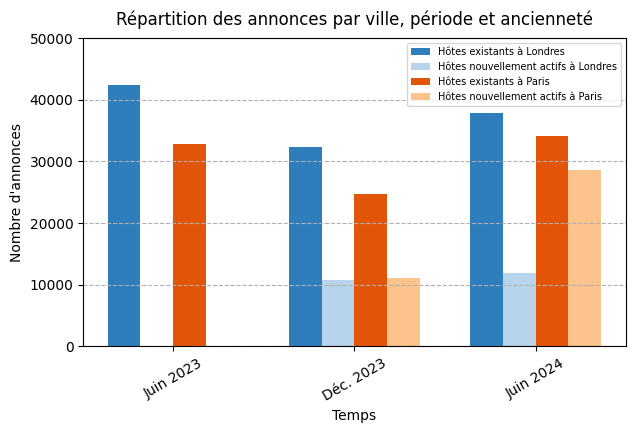

In [32]:


pivot=pivot_listings.copy()

times = sorted(pivot["time"].unique())
x = np.arange(len(times))

width = 0.18  # 因为现在有4个柱子

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.7, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.7, n))


fig, ax = plt.subplots(figsize=(7,4))

for i, t in enumerate(times):
    data = pivot[pivot["time"] == t]

    lond = data[data["in_paris"] == 0]
    paris = data[data["in_paris"] == 1]

    # Londres
    ax.bar(x[i] - 1.5*width, lond["ancien"], width,
           color=london_colors[1],
           label="Hôtes existants à Londres" if i == 0 else "")

    ax.bar(x[i] - 0.5*width, lond["nouveau"], width,
           color=london_colors[0],
           label="Hôtes nouvellement actifs à Londres" if i == 0 else "")

    # Paris
    ax.bar(x[i] + 0.5*width, paris["ancien"], width,
           color=paris_colors[1],
           label="Hôtes existants à Paris" if i == 0 else "")

    ax.bar(x[i] + 1.5*width, paris["nouveau"], width,
           color=paris_colors[0],
           label="Hôtes nouvellement actifs à Paris" if i == 0 else "")
ax.set_xticks(x)
ax.set_xticklabels(['Juin 2023','Déc. 2023',"Juin 2024"])
ax.tick_params(axis="x", rotation=30)
ax.set_ylim(0, 50000)
ax.set_xlabel("Temps")
ax.set_ylabel("Nombre d'annonces")
ax.set_title("Répartition des annonces par ville, période et ancienneté", pad=10)
ax.legend(fontsize=7)
ax.grid(axis='y', linestyle='--')

In [33]:
agg = (
    df_all
    .groupby(["time", "in_paris", "is_new_host"])
    ['host_id'].nunique()#size()
    .reset_index(name="count")
)
display(agg)

pivot = agg.pivot_table(
    index=["time", "in_paris"],
    columns="is_new_host",
    values="count",
    fill_value=0
).reset_index()

pivot.columns = ["time", "in_paris", "ancien", "nouveau"]
pivot["total"] = pivot["ancien"] + pivot["nouveau"]
pivot["share_new"] = pivot["nouveau"] / pivot["total"]
display(pivot)

pivot_hosts=pivot.copy()


,time,in_paris,is_new_host,count
0,2306,0,0,23211
1,2306,1,0,22426
2,2312,0,0,15811
3,2312,0,1,8497
4,2312,1,0,14956
5,2312,1,1,9922
6,2406,0,0,17465
7,2406,0,1,9325
8,2406,1,0,19497
9,2406,1,1,26349


,time,in_paris,ancien,nouveau,total,share_new
0,2306,0,23211.0,0.0,23211.0,0.000000
1,2306,1,22426.0,0.0,22426.0,0.000000
2,2312,0,15811.0,8497.0,24308.0,0.349556
3,2312,1,14956.0,9922.0,24878.0,0.398826
4,2406,0,17465.0,9325.0,26790.0,0.348078
5,2406,1,19497.0,26349.0,45846.0,0.574728


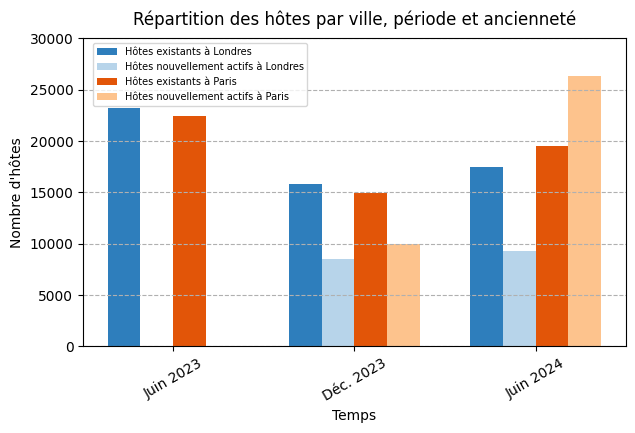

In [34]:

pivot=pivot_hosts.copy()

times = sorted(pivot["time"].unique())
x = np.arange(len(times))

width = 0.18  # 因为现在有4个柱子

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.7, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.7, n))


fig, ax = plt.subplots(figsize=(7,4))

for i, t in enumerate(times):
    data = pivot[pivot["time"] == t]

    lond = data[data["in_paris"] == 0]
    paris = data[data["in_paris"] == 1]

    # Londres
    ax.bar(x[i] - 1.5*width, lond["ancien"], width,
           color=london_colors[1],
           label="Hôtes existants à Londres" if i == 0 else "")

    ax.bar(x[i] - 0.5*width, lond["nouveau"], width,
           color=london_colors[0],
           label="Hôtes nouvellement actifs à Londres" if i == 0 else "")

    # Paris
    ax.bar(x[i] + 0.5*width, paris["ancien"], width,
           color=paris_colors[1],
           label="Hôtes existants à Paris" if i == 0 else "")

    ax.bar(x[i] + 1.5*width, paris["nouveau"], width,
           color=paris_colors[0],
           label="Hôtes nouvellement actifs à Paris" if i == 0 else "")
ax.set_xticks(x)
ax.set_xticklabels(['Juin 2023','Déc. 2023',"Juin 2024"])

ax.tick_params(axis="x", rotation=30)
ax.set_ylim(0, 30000)
ax.set_xlabel("Temps")
ax.set_ylabel("Nombre d'hôtes")
ax.set_title("Répartition des hôtes par ville, période et ancienneté", pad=10)
ax.legend(fontsize=7,loc="upper left", bbox_to_anchor=(0.01, 1))

ax.grid(axis='y', linestyle='--')

### description sur les tactiques : 2312 + 2406

In [35]:
tactics_pic_labels=['portrait','photo de vie','sans personne']
var_map=dict(zip(tactics_pic_dummies,tactics_pic_labels))
var_map

{'is_portrait': 'portrait',
 'is_lifestyle': 'photo de vie',
 'no_person': 'sans personne'}

In [36]:
from scipy import stats

def ttest_new_old_alltime(df,in_paris=[0, 1], vars=['authenticité']):
    # check time & in_paris
    df_t=df.copy()        
    # df_t = df_t[df_t['time'].isin(times)]
    df_t = df_t[df_t['in_paris'].isin(in_paris)]

    print(df.shape, '=>', df_t.shape)
    
    groups_in_paris=df_t['in_paris'].unique()
    # groups_time=df_t['time'].unique()
    # print(groups_in_paris)
    
    rows=[]
    for p in groups_in_paris:        
        for var in vars:
            sub = df_t[(df_t['in_paris'] == p)]# impo!!
            new = sub[sub['is_new_host'] == 1][var].dropna()
            old = sub[sub['is_new_host'] == 0][var].dropna()

            t_stat, p_value = stats.ttest_ind(new, old, equal_var=False)
            sig=p_to_sig(p_value)
            
            row_new= pd.DataFrame({
                # "time": [time],
                "in_paris":[p],
                "variable":var,
                "t_stat": [t_stat],
                "p_value": [p_value],
                "sig":[sig],
                'is_new_host':1,
                'mean':[new.mean()],
                'label':f"{var_map.get(var,'') if var in var_map.keys() else var}"
            })
            
            row_old= pd.DataFrame({
                # "time": [time],
                "in_paris":[p],
                "variable":var,
                "t_stat": [t_stat],
                "p_value": [p_value],
                "sig":[sig],
                'is_new_host':0,
                'mean':[old.mean()],
                'label':f"{var_map.get(var,'') if var in var_map.keys() else var}"
            })
            
            rows.append(row_new)
            rows.append(row_old)
    return pd.concat(rows, axis=0)


# ---plot data---    
ordered_tactics=tactics_bio + tactics_pic_dummies
# tactics=['authenticité']
df=df_all[df_all['time']!='2306'].copy()
print(df.shape)
tactcis_new_old_by_city_2=ttest_new_old_alltime(df,in_paris=[0, 1], vars=ordered_tactics)
tactcis_new_old_by_city_2

(191595, 131)
(191595, 131) => (191595, 131)


,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,0,ouverture,19.236613,3.941955e-82,***,1,-0.043344,ouverture
0,0,ouverture,19.236613,3.941955e-82,***,0,-0.135141,ouverture
0,0,authenticité,36.607882,2.473451e-289,***,1,-0.068722,authenticité
0,0,authenticité,36.607882,2.473451e-289,***,0,-0.256846,authenticité
0,0,sociabilité,6.856773,7.132533e-12,***,1,-0.059650,sociabilité
0,0,sociabilité,6.856773,7.132533e-12,***,0,-0.093857,sociabilité
0,0,auto_promotion,-42.976666,0.000000e+00,***,1,0.042923,auto_promotion
0,0,auto_promotion,-42.976666,0.000000e+00,***,0,0.266127,auto_promotion
0,0,exemplarité,-13.115600,3.133601e-39,***,1,-0.008423,exemplarité
0,0,exemplarité,-13.115600,3.133601e-39,***,0,0.053093,exemplarité


in_paris=0, tactics:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
10
in_paris=1, tactics:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
10


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\4021975933.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


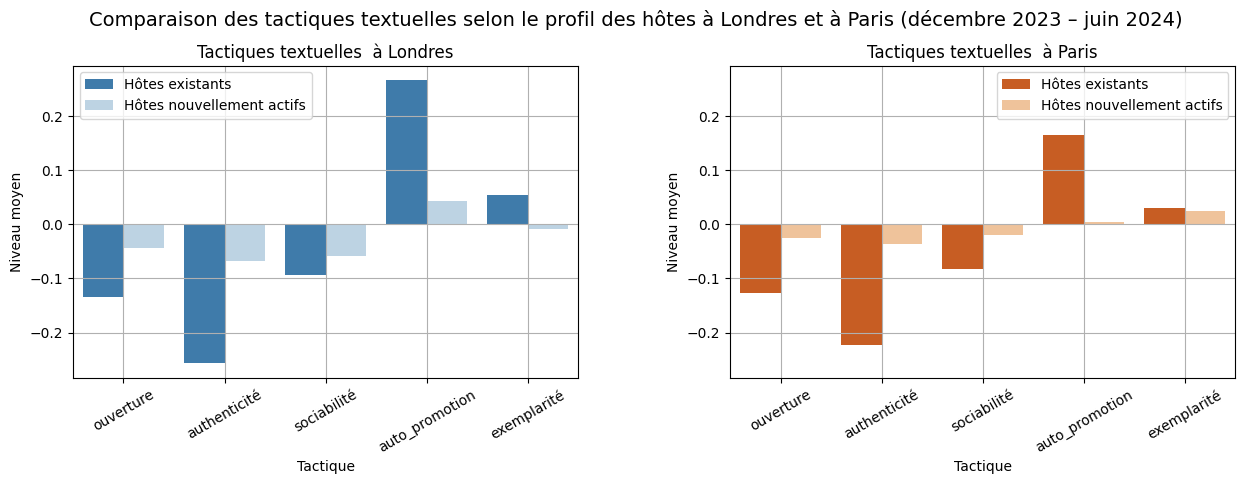

In [37]:

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(15, 4)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2],sharey=ax1)#**
axes.extend([ax1, ax2])

# # ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.7, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.7, n))

# ---plot---
df_plot=tactcis_new_old_by_city_2.copy()
tactics=tactics_bio
subplot_col1='in_paris'
list_tactics=[tactics_bio]

# subplot_col2='time'
i=0

for j, tactics in enumerate(list_tactics):
    
    for p in df_plot[subplot_col1].unique():
        print(f"{subplot_col1}={p}, tactics:{tactics}")
        ax=axes[i]
        
        # ---sub data---
        sub=df_plot[(df_plot[subplot_col1]==p)&(df_plot['variable'].isin(tactics))]
        print(len(sub))#==10==5 tactics *2 new/old
        
        if p==1:
            palette=dict(zip(sub['is_new_host'], paris_colors))
        else :
            palette=dict(zip(sub['is_new_host'], london_colors))
    
        sns.barplot(
            data=sub,   
            x='label',
            y="mean",
            hue="is_new_host",
            palette=palette,
            ax=ax,
        )    

        ax.set_xlabel("Tactique")
        ax.set_ylabel("Niveau moyen")
        ax.tick_params(axis="x",rotation=30)
        if j==1:
            ax.set_ylim(0,0.5)
        
        ax.set_title(f"Tactiques {'textuelles' if j==0 else 'visuelles'}  à {'Paris' if p==1 else 'Londres'}")
        
        handles, labels = ax.get_legend_handles_labels()
        new_labels = ["Hôtes existants", "Hôtes nouvellement actifs"]
        ax.legend(handles, new_labels)# title="Type d'hôte"
        
        ax.grid()
        i+=1
        

## ---legend 2facets----
fig.suptitle(
        # "Effets marginaux des tactiques visuelles entre les groupes",
        "Comparaison des tactiques textuelles selon le profil des hôtes à Londres et à Paris (décembre 2023 – juin 2024)",
        # "Comparaison des tactiques textuelles entre les noueaux et anciens hôtes à Londres et à Paris",
        fontsize=14,
        y=1.02
    )
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.1)#控制子图到底的距离，给text留出空间
plt.show()


in_paris=0, tactics:['is_portrait', 'is_lifestyle', 'no_person']
6
in_paris=1, tactics:['is_portrait', 'is_lifestyle', 'no_person']
6


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\3993167151.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


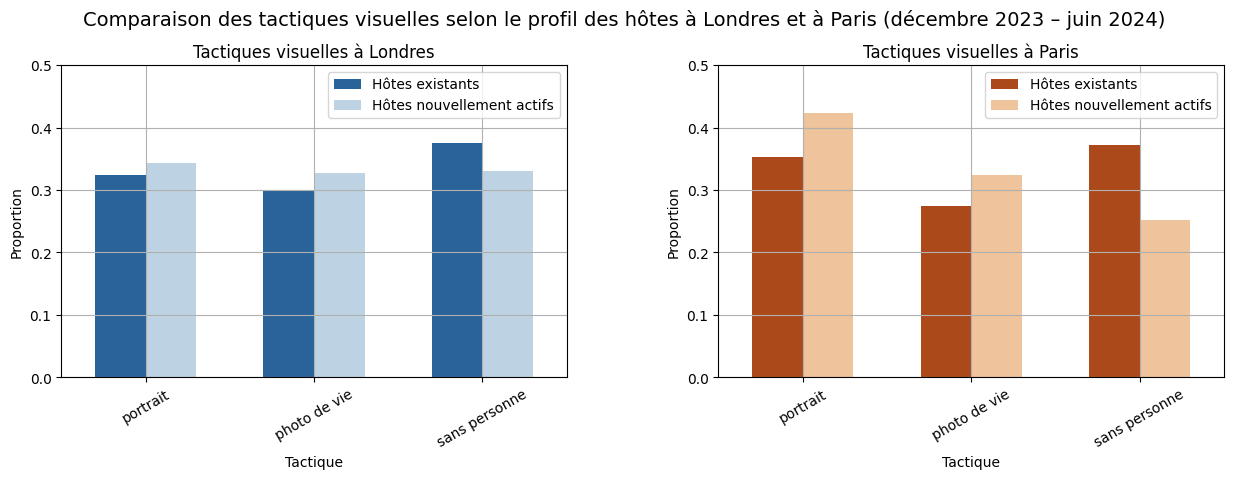

In [38]:

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(15, 4)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2],sharey=ax1)#**
axes.extend([ax1, ax2])


# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))


# ---plot---
df_plot=tactcis_new_old_by_city_2.copy()
tactics=tactics_pic_dummies
subplot_col1='in_paris'
list_tactics=[tactics_pic_dummies]

# subplot_col2='time'
i=0

for j, tactics in enumerate(list_tactics):
    
    for p in df_plot[subplot_col1].unique():
        print(f"{subplot_col1}={p}, tactics:{tactics}")
        ax=axes[i]
        
        # ---sub data---
        sub=df_plot[(df_plot[subplot_col1]==p)&(df_plot['variable'].isin(tactics))]
        print(len(sub))#==10==5 tactics *2 new/old
        
        if p==1:
            palette=dict(zip(sub['is_new_host'], paris_colors))
        else :
            palette=dict(zip(sub['is_new_host'], london_colors))
    
        sns.barplot(
            data=sub,   
            x='label',
            y="mean",
            hue="is_new_host",
            palette=palette,
            ax=ax,
            width=0.6
        )    

        ax.set_xlabel("Tactique")
        ax.set_ylabel("Proportion")
        ax.tick_params(axis="x",rotation=30)
        # if j==1:
        ax.set_ylim(0,0.5)
        
        ax.set_title(f"Tactiques visuelles à {'Paris' if p==1 else 'Londres'}")
        
        handles, labels = ax.get_legend_handles_labels()
        new_labels = ["Hôtes existants", "Hôtes nouvellement actifs"]
        ax.legend(handles, new_labels)
        
        ax.grid()
        i+=1
        

## ---legend 2facets----
fig.suptitle(
        # "Effets marginaux des tactiques visuelles entre les groupes",
        "Comparaison des tactiques visuelles selon le profil des hôtes à Londres et à Paris (décembre 2023 – juin 2024)",
        # "Comparaison des tactiques visuelles entre les noueaux et anciens hôtes à Londres et à Paris",
        fontsize=14,
        y=1.02
    
    )
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.1)#控制子图到底的距离，给text留出空间
plt.show()

## OLS DID hetero

In [64]:
models_hetero=[]
tactics=tactics_bio+tactics_pic_dummies
for var in tactics:
    
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
            "number_of_reviews_ltm + "
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate +  C(host_response_time)+"
            "has_text + lang_en + lang_fr + text_length+"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "C(time) + in_paris * C(time)*is_new_host"
    )    
    df=df_all.copy()
    model_tactic=smf.ols(formula, data=df).fit()
    models_hetero.append(model_tactic)


## dynamique des did

In [65]:
def get_event_study_hetero(model, var, times=[2312, 2406], baseline=2306):
    import pandas as pd
    
    results = []
    # --- baseline ---
    for is_new_host in [0,1]:
        results.append({
            "time": baseline,
            "is_new_host": is_new_host,
            "coef": 0,
            "se": 0,
            "ci_low": 0,
            "ci_high": 0,
            "pval": 1,
            "sig": "",
            "variable": var
        })

    # --- loop over time ---
    for t in times:

        # =====================
        # 1. old
        # =====================
        term_old = f"in_paris:C(time)[T.{t}]"
        test_old = model.t_test(term_old)

        coef = float(test_old.effect[0])
        se = float(test_old.sd[0])
        pval = float(test_old.pvalue)

        results.append({
            "time": t,
            "is_new_host":0,
            "coef": coef,
            "se": se,
            "ci_low": coef - 1.96 * se,
            "ci_high": coef + 1.96 * se,
            "pval": pval,
            "sig": p_to_sig(pval),
            "variable": var
        })

        # =====================
        # 2. new
        # =====================
        term_new = (
            f"in_paris:C(time)[T.{t}] + "
            f"in_paris:C(time)[T.{t}]:is_new_host"
        )

        test_new = model.t_test(term_new)

        coef = float(test_new.effect[0])
        se = float(test_new.sd[0])
        pval = float(test_new.pvalue)

        results.append({
            "time": t,
            "is_new_host":1,
            "coef": coef,
            "se": se,
            "ci_low": coef - 1.96 * se,
            "ci_high": coef + 1.96 * se,
            "pval": pval,
            "sig": p_to_sig(pval),
            "variable": var,
            'label':f"{var_map.get(var,'') if var in var_map.keys() else var}"
        })

    df = pd.DataFrame(results)
    df = df.sort_values(["is_new_host", "time"])

    return df

In [70]:
results=[]
tactics=tactics_bio+tactics_pic_dummies
for var, model_new in zip(tactics, models_hetero):   
    res=get_event_study_hetero(model_new, var)
    results.append(res)

results_did_evolution_hetero=pd.concat(results, axis=0)
display(results_did_evolution_hetero)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\2056347562.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  se = float(test_old.sd[0])
C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\2056347562.py:55: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  se = float(test_new.sd[0])


,time,is_new_host,coef,se,ci_low,ci_high,pval,sig,variable,label
0,2306,0,0.000000,0.000000,0.000000,0.000000,1.000000e+00,,ouverture,NaN
2,2312,0,0.003171,0.007036,-0.010621,0.016962,6.522603e-01,,ouverture,NaN
4,2406,0,0.010097,0.006595,-0.002830,0.023024,1.258038e-01,,ouverture,NaN
1,2306,1,0.000000,0.000000,0.000000,0.000000,1.000000e+00,,ouverture,NaN
3,2312,1,0.021767,0.008021,0.006046,0.037489,6.653309e-03,**,ouverture,ouverture
5,2406,1,-0.026194,0.007501,-0.040896,-0.011491,4.796863e-04,***,ouverture,ouverture
0,2306,0,0.000000,0.000000,0.000000,0.000000,1.000000e+00,,authenticité,NaN
2,2312,0,0.029687,0.007285,0.015409,0.043966,4.599974e-05,***,authenticité,NaN
4,2406,0,0.024809,0.006828,0.011426,0.038193,2.798776e-04,***,authenticité,NaN
1,2306,1,0.000000,0.000000,0.000000,0.000000,1.000000e+00,,authenticité,NaN


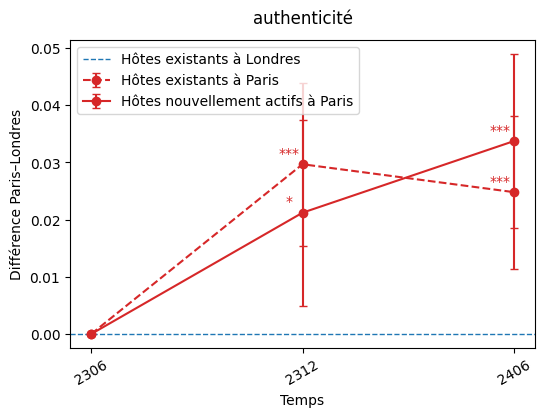

In [71]:
def plot_one_did_hetero(data, axes=None, i=0, var='authenticité', title=None): 
    if axes is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        ax = axes[i]

    df = data.copy()
    sub = df[df["variable"] == var].copy()
    sub = sub.sort_values(["is_new_host", "time"])
    color = 'tab:red'
    # display(sub)
    
    # x 轴（统一）
    times = sorted(sub["time"].unique())
    x_map = {t:i for i,t in enumerate(times)}

    # --- 两组 ---
    for is_new, linestyle, label in zip(
        [0, 1],
        ['--', '-'],   # 老虚线，新实线
        ['Hôtes existants à Paris', 'Hôtes nouvellement actifs à Paris']
    ):
        d = sub[sub["is_new_host"] == is_new].copy()
        d = d.sort_values("time")

        x = [x_map[t] for t in d["time"]]

        # --- errorbar ---
        ax.errorbar(
            x,
            d["coef"],
            yerr=[
                d["coef"] - d["ci_low"],
                d["ci_high"] - d["coef"]
            ],
            fmt='o',
            linestyle=linestyle,
            capsize=3,
            color=color,
            label=label
        )

        # --- sig ---
        for xi, yi, sig in zip(x, d["coef"], d["sig"]):
            ax.annotate(
                sig,
                xy=(xi, yi),
                xytext=(-10, 5),              # 向上偏移 5 points
                textcoords="offset points",
                ha='center',
                color=color,
                fontsize=10
            )
    
    
    # --- baseline ---
    ax.axhline(0, linestyle="--", color="tab:blue", linewidth=1, label="Hôtes existants à Londres")

    # --- x  ---
    ax.set_xticks(list(x_map.values()))
    ax.set_xticklabels(times)
    ax.tick_params(axis="x", rotation=30)

    # --- labels ---
    ax.set_xlabel("Temps")
    ax.set_ylabel("Différence Paris–Londres")

    # --- title ---
    title = var if title is None else title
    ax.set_title(title, pad=12)

    if axes is None:
        ax.legend()
        
plot_one_did_hetero(results_did_evolution_hetero, var="authenticité")

C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\394781060.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.9,1])


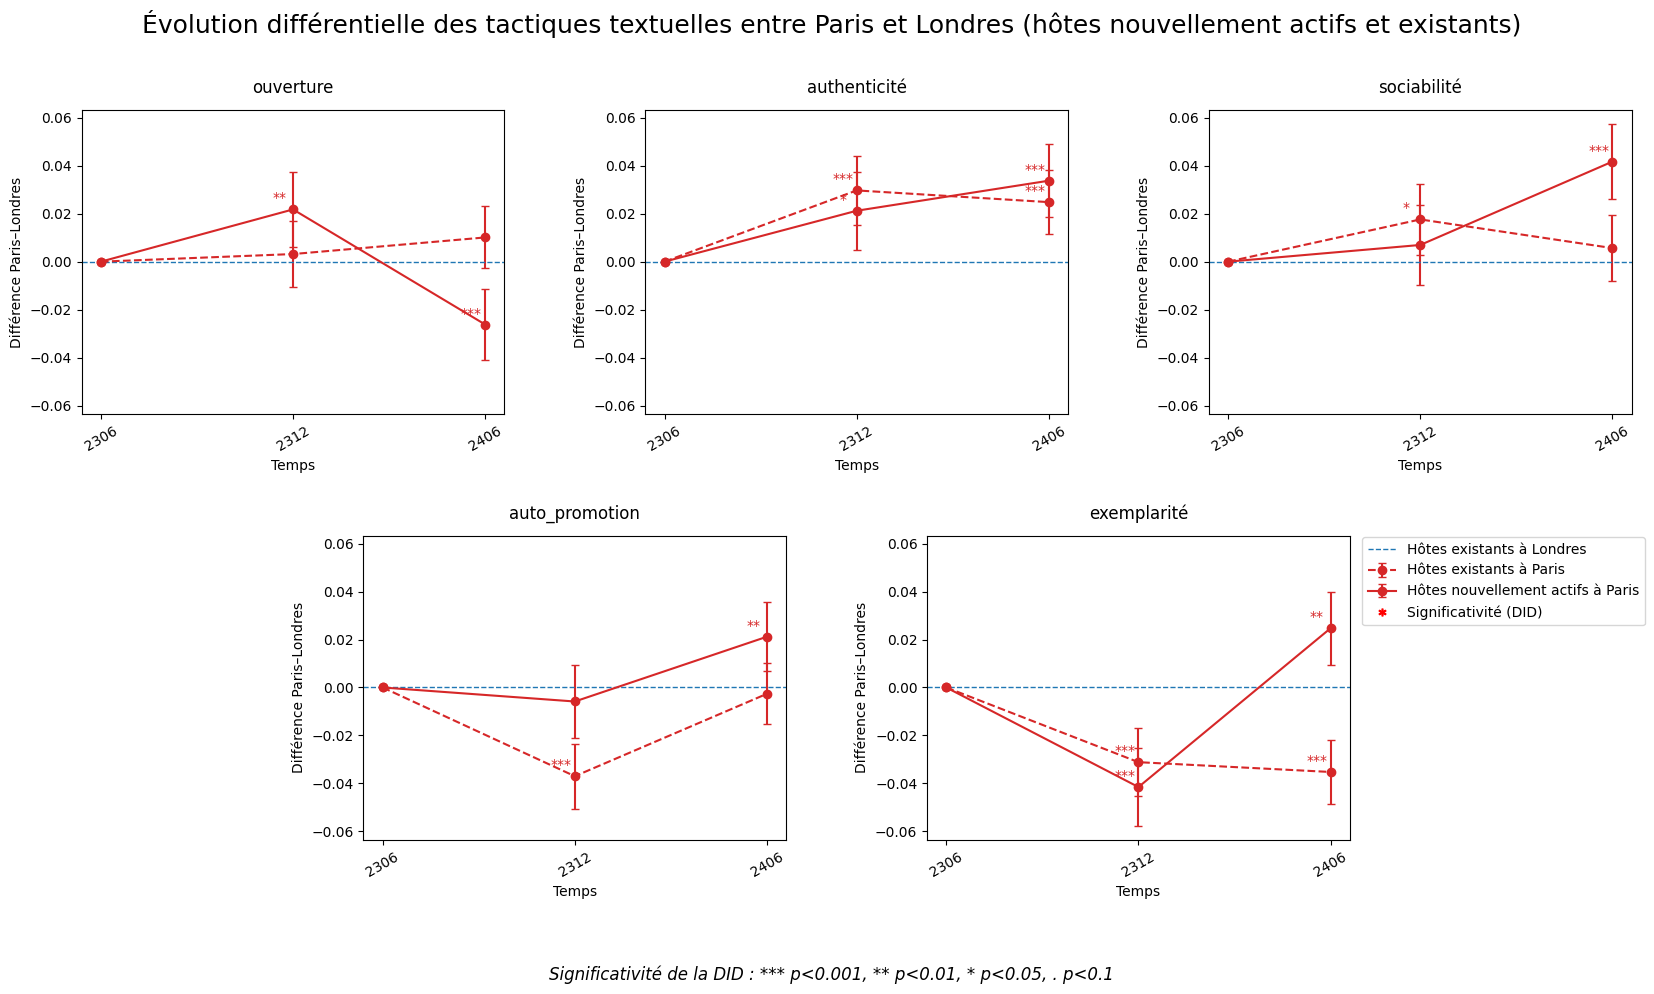

In [72]:
from utils import modeling_did
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_did

# ---layout---
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,10))# sharey=True
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 4:6], sharey=ax1)
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3], sharey=ax1)
ax5 = fig.add_subplot(gs[1, 3:5], sharey=ax1)
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
# n_to_plot = min(len(tactics), len(axes))


df_plot=results_did_evolution_hetero.copy()#[results_did_evolution['variable'].isin(tactics)].copy()

for i, var in enumerate(tactics_bio):
    plot_one_did_hetero(data=df_plot, axes=axes, i=i, var=var, title=None)
    
# --------------------legend------------------------
fig.suptitle(
        "Évolution différentielle des tactiques textuelles entre Paris et Londres (hôtes nouvellement actifs et existants)",
        fontsize=18,
        y=0.98 #大标题到子图的距离, 越大越远
    )

from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
# --- add custom legend :sig note ---
handles.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='red', markersize=5,
           label='Significativité (DID)')
)
labels = labels + [
    "Significativité (DID)"
]

fig.legend(
    handles,
    labels,
    fontsize=10,
    loc="upper right",
    bbox_to_anchor=(0.91,0.46) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 0.9,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()

C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\1793733620.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8,1])


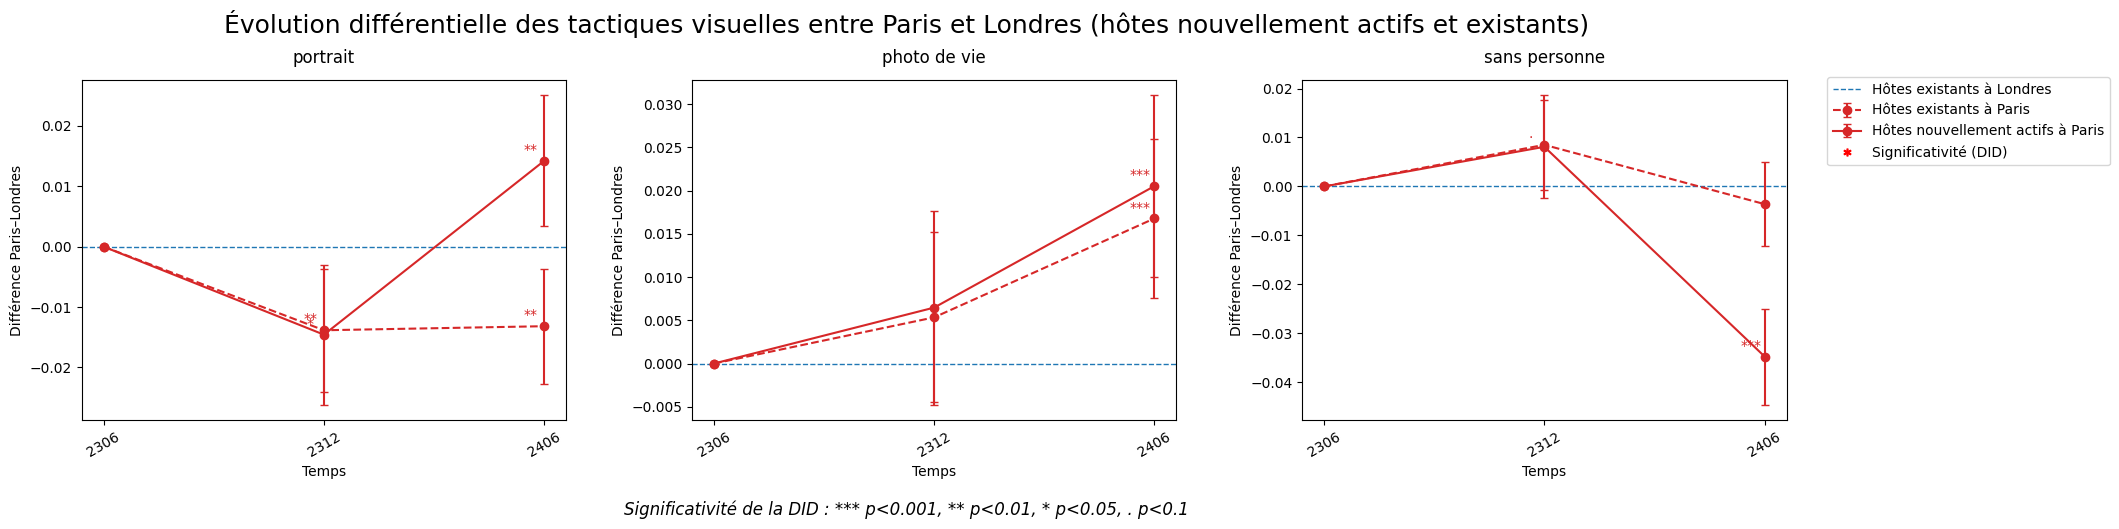

In [73]:
# ---layout---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(22,5))# sharey=True
gs = gridspec.GridSpec(1, 6, figure=fig, hspace=0.4, wspace=0.7)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])


## plot

tactics_pic_labels=['portrait','photo de vie','sans personne']
var_map=dict(zip(tactics_pic_dummies,tactics_pic_labels))

df_plot=results_did_evolution_hetero.copy()

for i, var in enumerate(tactics_pic_dummies):
    plot_one_did_hetero(data=df_plot, axes=axes, i=i, var=var, title=var_map.get(var))
    
# layout 3facets:
fig.suptitle(
        "Évolution différentielle des tactiques visuelles entre Paris et Londres (hôtes nouvellement actifs et existants)",
        fontsize=18,
        y=1.02
    )

# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
# --- add custom legend :sig note ---
handles.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='red', markersize=5,
           label='Significativité (DID)')
)
labels = labels + [
    "Significativité (DID)"
]

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.05,0.9) # legend (x, y)，x>1则在图外, y=0在底线
)
plt.figtext(
    0.5, 0.01,
    "Significativité de la DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 0.8,1])
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

## variation de DID hetero

In [74]:
tactics=tactics_bio+tactics_pic_dummies
tactics

['ouverture',
 'authenticité',
 'sociabilité',
 'auto_promotion',
 'exemplarité',
 'is_portrait',
 'is_lifestyle',
 'no_person']

In [75]:
specs=[
    # constants: time=2312-2406, in_paris: paris-london, 
    # is_new_host, terms 
    (1, """
        in_paris:C(time)[T.2406] + in_paris:C(time)[T.2406]:is_new_host 
        - in_paris:C(time)[T.2312] - in_paris:C(time)[T.2312]:is_new_host
        """), 
    # - C(time)[T.2406]:is_new_host
    # + C(time)[T.2312]:is_new_host
        
    (0, """
        in_paris:C(time)[T.2406]
        - in_paris:C(time)[T.2312]
        """) 
#       - C(time)[T.2406]
#         + C(time)[T.2312]
]

df=df_all.copy()
results=[]

tactics_pic_labels=['portrait','photo de vie','sans personne']
var_map=dict(zip(tactics_pic_dummies,tactics_pic_labels))

for var, model_new in zip(tactics, models_hetero):   
    print(var)

    for i, (new, term) in enumerate(specs):
        test = model_new.t_test(term)
        sig=p_to_sig(test.pvalue)
        res= pd.DataFrame({
            'variable':var,
            "is_new_host":new,
            "coef": test.effect[0],
            "se": test.sd[0],
            "pval": test.pvalue,
            "sig":sig,
            "ci_low": test.conf_int()[0][0],
            "ci_high": test.conf_int()[0][1],
            'label':f"{var_map.get(var,'') if var in var_map.keys() else var}"
        })
        results.append(res)
    # break

results_ddd_new=pd.concat(results, axis=0)
display(results_ddd_new)  


ouverture
authenticité
sociabilité
auto_promotion
exemplarité
is_portrait
is_lifestyle
no_person


,variable,is_new_host,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,1,-0.047961,0.010951,1.188402e-05,***,-0.069424,-0.026498,ouverture
0,ouverture,0,0.006926,0.007089,3.285956e-01,,-0.006969,0.020821,ouverture
0,authenticité,1,0.012520,0.011337,2.694378e-01,,-0.009700,0.034741,authenticité
0,authenticité,0,-0.004878,0.007340,5.063110e-01,,-0.019263,0.009508,authenticité
0,sociabilité,1,0.034737,0.011724,3.048703e-03,**,0.011758,0.057716,sociabilité
0,sociabilité,0,-0.011947,0.007590,1.154902e-01,,-0.026824,0.002930,sociabilité
0,auto_promotion,1,0.026999,0.010687,1.152112e-02,*,0.006054,0.047945,auto_promotion
0,auto_promotion,0,0.034360,0.006918,6.820463e-07,***,0.020800,0.047920,auto_promotion
0,exemplarité,1,0.066196,0.011356,5.579358e-09,***,0.043938,0.088454,exemplarité
0,exemplarité,0,-0.004086,0.007352,5.783685e-01,,-0.018495,0.010324,exemplarité


is_new_host=1
is_new_host=0


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\4112739329.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


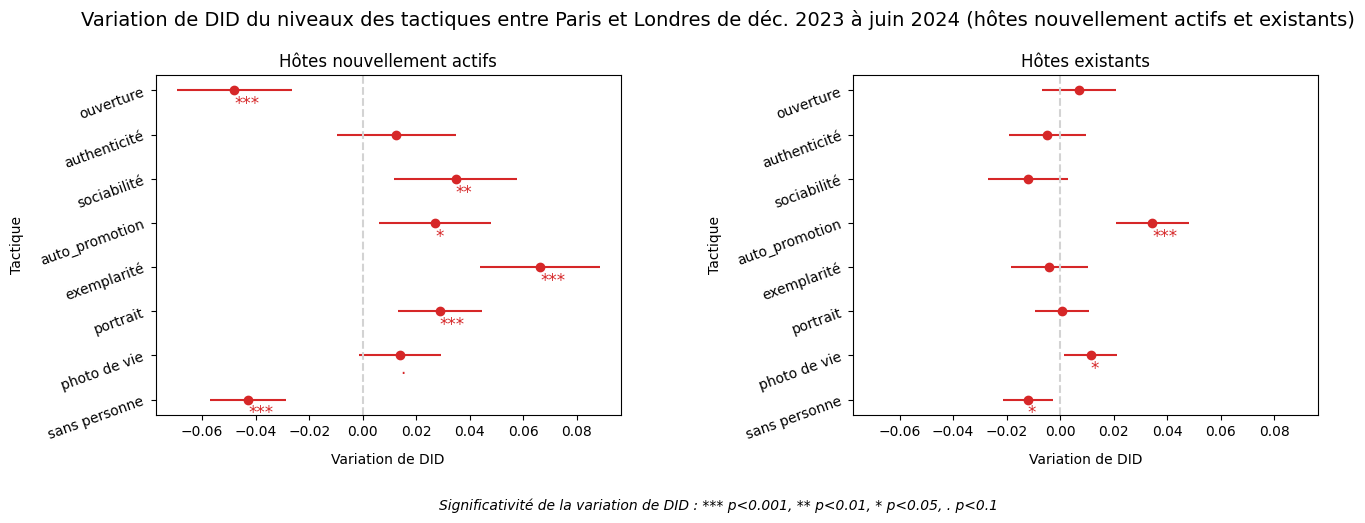

In [76]:
## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(15, 5)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.5)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharex=ax1)#**
axes.extend([ax1, ax2])

# ---color---
change_colors='tab:red'

# ---vis----
tactics=tactics_bio+tactics_pic_dummies

df_plot=results_ddd_new[results_ddd_new['variable'].isin(tactics)].copy()#***

subplot_col="is_new_host"

for i, new in enumerate(df_plot[subplot_col].unique()):
    print(f"{subplot_col}={new}")
    
    sub=df_plot[df_plot[subplot_col]==new].copy()
    order=tactics[::-1]
    sub = sub.set_index("variable").loc[order].reset_index()
    # display(sub)

    ax=axes[i]
    ax.errorbar(
        x=sub["coef"],
        y=sub["label"],
        # y=y,
        xerr=[sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]],
        fmt='o', 
        color=change_colors,
        # linestyle='-' if new==1 else '--'
    )
    # ---sig---
    for _, row in sub.iterrows():
        ax.annotate(
            row["sig"],
            xy=(row["coef"], row["label"]),
            xytext=(0, -10),         
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=12,
            color=change_colors
    )    
            
    ax.axvline(0, linestyle='--', color="lightgray", label="Variation de Londres")    
    ax.set_xlabel(f"Variation de DID", labelpad=10)
    ax.set_ylabel('Tactique', labelpad=10)
    ax.tick_params(axis='y', rotation=20)
    ax.set_title(f"{'Hôtes nouvellement actifs' if new==1 else 'Hôtes existants'}")
    
    

## ---legend 2facets----
fig.suptitle(
    "Variation de DID du niveaux des tactiques entre Paris et Londres de déc. 2023 à juin 2024 (hôtes nouvellement actifs et existants)", 
    fontsize=14,
    y=1.01
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la variation de DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

## graphique en niveau hétéro:

In [88]:

# 2312 vs 2406
def ttest_by_time(df, times: list=["2306"], in_paris=[0, 1], is_new_host=[1], vars=tactics_bio):
    # ---data---
    df_t=df.copy()        
    df_t = df_t[df_t['time'].isin(times)]
    df_t = df_t[df_t['in_paris'].isin(in_paris)]
    df_t = df_t[df_t['is_new_host'].isin(is_new_host)]
    print(df.shape, '=>', df_t.shape)
    print(df_t[['is_new_host','time', "in_paris"]].value_counts(dropna=False))
    groups_in_paris=df_t['in_paris'].unique()
    groups_new_host=df_t['is_new_host'].unique()
    # print(groups_in_paris)
    var_map={
        'is_portrait':'portrait',
        'is_lifestyle':'photo de vie',
        'no_person':'sans personne'
    }
    
    rows=[]
    for new in groups_new_host: # 统一
        for p in groups_in_paris: #分图 
            for var in vars:
                sub = df_t[(df_t['is_new_host'] == new) & (df_t['in_paris'] == p)]                
                # hue
                early = sub[sub['time'] == "2312"][var].dropna()
                late = sub[sub['time'] == "2406"][var].dropna()
                
                t_stat, p_value = stats.ttest_ind(early, late, equal_var=False)
                sig=p_to_sig(p_value)
                change=late.mean()-early.mean()
                            
                row_early= pd.DataFrame({
                    "time": ["2312"],
                    "in_paris":[p],
                    "variable":var,
                    "t_stat": [t_stat],
                    "p_value": [p_value],
                    "sig":[sig],
                    'is_new_host':new,
                    'mean':[early.mean()],
                    'label':f"{var_map.get(var,'') if var in var_map.keys() else var}",
                    "change":"+" if change > 0 else "-"

                })
                row_late= pd.DataFrame({
                    "time": ["2406"],
                    "in_paris":[p],
                    "variable":var,
                    "t_stat": [t_stat],
                    "p_value": [p_value],
                    "sig":[sig],
                    'is_new_host':new,
                    'mean':[late.mean()],
                    'label':f"{var_map.get(var,'') if var in var_map.keys() else var}",
                    "change":"+" if change > 0 else "-"

                })
                rows.append(row_early)
                rows.append(row_late)
    return pd.concat(rows, axis=0)

In [89]:
# 每个时期地点类型房东的平均值
# importlib.reload(desc_new_old)
# from utils.desc_new_old import ttest_by_time


df_plot_time=ttest_by_time(df=df_all, 
                           times=["2312","2406"], in_paris=[0, 1], is_new_host=[0, 1], 
                           vars=tactics_bio+tactics_pic_dummies)
df_plot_time

(266852, 131) => (191595, 131)
is_new_host  time  in_paris
0            2406  0           37937
                   1           34176
             2312  0           32360
1            2406  1           28562
0            2312  1           24780
1            2406  0           11919
             2312  1           11049
                   0           10812
Name: count, dtype: int64


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label,change
0,2312,0,ouverture,-2.769081,0.005626,**,1,-0.054907,ouverture,+
0,2406,0,ouverture,-2.769081,0.005626,**,1,-0.032854,ouverture,+
0,2312,0,authenticité,0.048290,0.961486,,1,-0.068509,authenticité,-
0,2406,0,authenticité,0.048290,0.961486,,1,-0.068915,authenticité,-
0,2312,0,sociabilité,0.249636,0.802871,,1,-0.058570,sociabilité,-
...,...,...,...,...,...,...,...,...,...,...
0,2406,1,is_portrait,2.771907,0.005575,**,0,0.347817,portrait,-
0,2312,1,is_lifestyle,2.238904,0.025166,*,0,0.279742,photo de vie,-
0,2406,1,is_lifestyle,2.238904,0.025166,*,0,0.271389,photo de vie,-
0,2312,1,no_person,-4.821333,0.000001,***,0,0.361380,sans personne,+


In [108]:
# results_ddd_new

0 ouverture
label=ouverture, is_new_host=1
label=ouverture, is_new_host=0
1 authenticité
label=authenticité, is_new_host=1
label=authenticité, is_new_host=0
2 sociabilité
label=sociabilité, is_new_host=1
label=sociabilité, is_new_host=0
3 auto_promotion
label=auto_promotion, is_new_host=1
label=auto_promotion, is_new_host=0
4 exemplarité
label=exemplarité, is_new_host=1
label=exemplarité, is_new_host=0


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\254770612.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


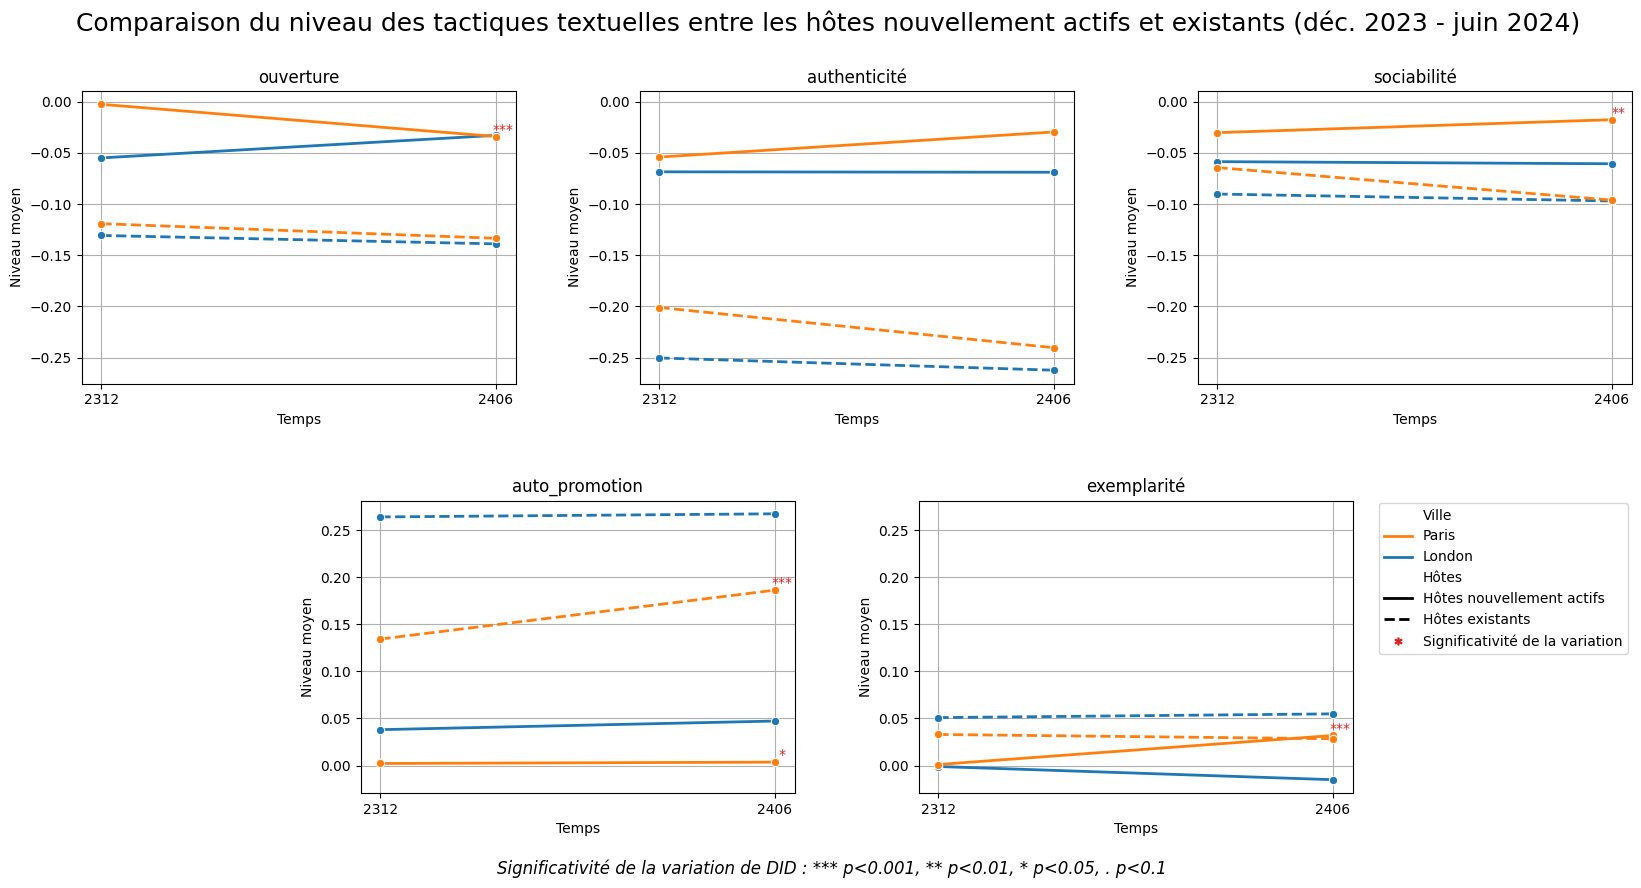

In [90]:
## new old hue:london/paris y=tactics_sig
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 1 # ==len(hue) 每组柱子的数量
# london_colors = blue_cmap(np.linspace(0.7, 0.8, n))
# paris_colors  = orange_cmap(np.linspace(0.7, 0.8, n))

london_colors="tab:blue"
paris_colors='tab:orange'
# paris:paris color
palette={
    0:london_colors,
    1:paris_colors
}

# -------------------layout 5 facets-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=0.8)

axes = []
# # 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 4:6], sharey=ax1)
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5], sharey=ax4)
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


# 每一个tac一个图，一个图中新老pl四条线, 新房东浅色，london蓝色，
# 每个 var 一张图
# x = time
# 线 = Paris vs London
# hue = new/old


subplot_col1='label'
subplot_col2='is_new_host'
# subplot_col3='is_new_host'
tactics=tactics_bio
df_plot=df_plot_time.copy()

# ---plt---
i=0
for var in tactics:
    ax=axes[i]
    print(i, var)    
    for new in df_plot[subplot_col2].unique():#*** 
       
        # ---sub data---
        print(f"{subplot_col1}={var}, {subplot_col2}={new}")#***        
        sub = df_plot[
            (df_plot[subplot_col1] == var) &
            (df_plot[subplot_col2] == new) 
        ].copy()
        # display(sub)
        # new/old
    
        sns.lineplot(
            data=sub,
            x="time",
            y="mean",
            hue="in_paris",
            palette=palette,
            marker="o",
            linestyle='-' if new==1 else '--',
            linewidth= 2,# if new==1 else 1.5,
            ax=ax,
            legend=False
        )
        
        # ---sig--- 
        sub_ddd=results_ddd_new[(results_ddd_new['label']==var)&(results_ddd_new['is_new_host']==new)]['sig'].iloc[0]
        for _, row in sub[(sub['in_paris']==1)&(sub['time']=="2406")].iterrows():
            # print(row)
            ax.annotate(sub_ddd,
                        xy=(row['time'], row['mean']),
                        xytext=(5,5),
                        textcoords='offset points',
                        ha='center',
                        va='center',
                        fontsize=10,
                        color='tab:red'
                        )
        
        
    #     break
    # break      
    ax.grid()
    ax.set_xlabel("Temps")
    ax.set_ylabel("Niveau moyen")
    ax.set_title(f"{var}")
    i+=1
    # break        
            
    
## ---legend 2facets----
fig.suptitle(
        f"Comparaison du niveau des tactiques textuelles entre les hôtes nouvellement actifs et existants (déc. 2023 - juin 2024) ",
        fontsize=18,
        y=0.97
    )
# ---custom legen---
legend_elements = []
    # ---标题：城市---
legend_elements.append(Line2D([], [], linestyle="none", label="Ville"))

legend_elements.append(
    Line2D([0], [0], color=paris_colors, lw=2, linestyle="-", label="Paris")
)
legend_elements.append(
    Line2D([0], [0], color=london_colors, lw=2, linestyle="-", label="London")
)

# ---标题：新老房东---
legend_elements.append(Line2D([], [], linestyle="none", label="Hôtes"))

legend_elements.append(
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Hôtes nouvellement actifs")
)
legend_elements.append(
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Hôtes existants")
)

# --- sig note ---
legend_elements.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='tab:red',markersize=5,
           label='Significativité de la variation')
)

fig.legend(
        handles=legend_elements,
        loc="upper left",
        bbox_to_anchor=(0.77, 0.43),
        frameon=True
    )

plt.figtext(
    0.5, 0.01,
    "Significativité de la variation de DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)

plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.1)#控制子图到底的距离，给text留出空间

plt.show()

0
label=portrait, is_new_host=1
label=portrait, is_new_host=0
1
label=photo de vie, is_new_host=1
label=photo de vie, is_new_host=0
2
label=sans personne, is_new_host=1
label=sans personne, is_new_host=0


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\1320132820.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.9, 1])# [left, bottom, right, top]


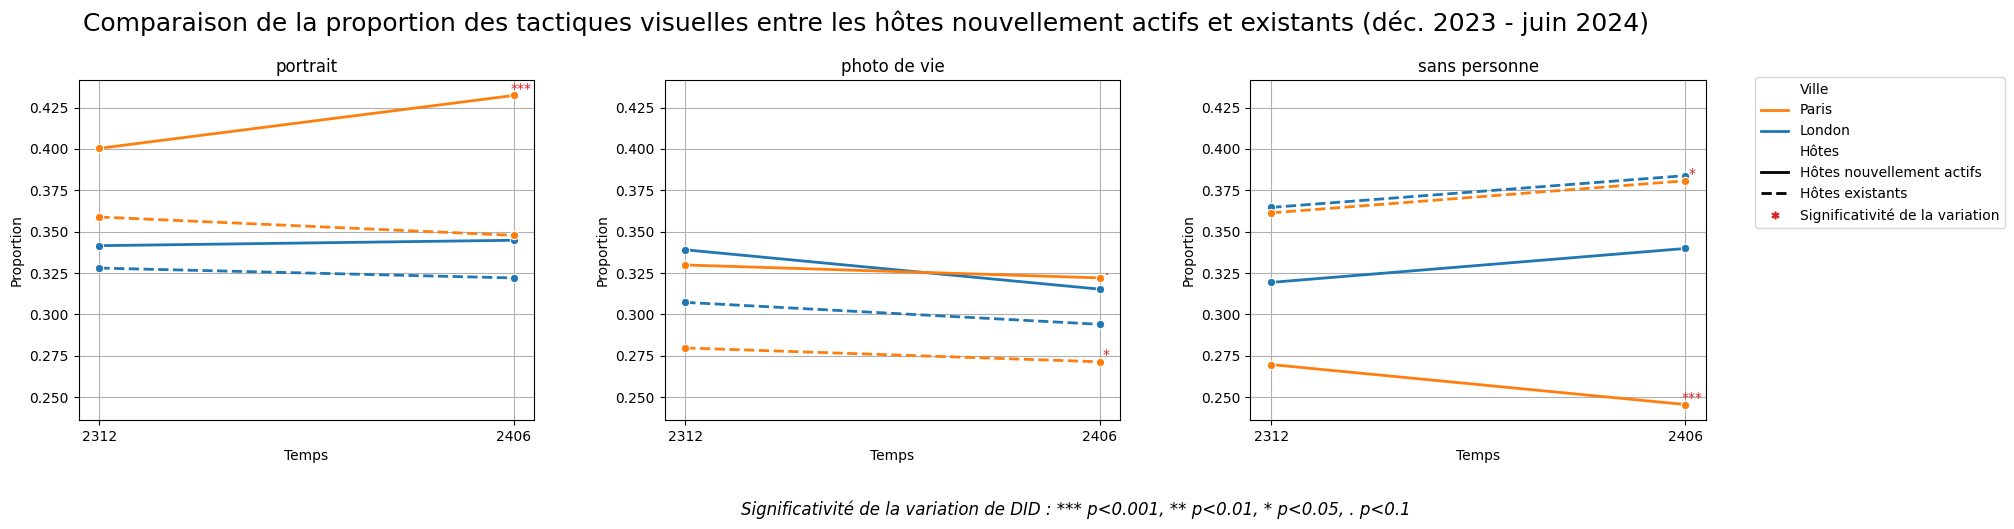

In [79]:
## new old hue:london/paris y=tactics_sig
import matplotlib.gridspec as gridspec

df_plot=df_plot_time.copy()

# paris:paris color
palette={
    0:'tab:blue',
    1:'tab:orange'
}

# -------------------layout 5 facets-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(21,5))
gs = gridspec.GridSpec(1, 6, figure=fig, hspace=0.4, wspace=0.8)

axes = []
# # 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 4:6], sharey=ax1)
axes.extend([ax1, ax2, ax3])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics), len(axes))


subplot_col1='label'
subplot_col2='is_new_host'
tactics=tactics_pic_labels
i=0
for var in tactics:
    ax=axes[i]
    print(i)    
    for new in df_plot[subplot_col2].unique():#*** 
       
                    
        # ---sub data---
        print(f"{subplot_col1}={var}, {subplot_col2}={new}")#***        
        sub = df_plot[
            (df_plot[subplot_col1] == var) &
            (df_plot[subplot_col2] == new) 
        ].copy()
        # display(sub)
        # new/old
    
        sns.lineplot(
            data=sub,
            x="time",
            y="mean",
            hue="in_paris",
            palette=palette,
            marker="o",
            linestyle='-' if new==1 else '--',
            linewidth= 2, # if new==1 else 1.5,
            ax=ax,
            legend=False
        )
        # ---sig--- 
        sub_ddd=results_ddd_new[(results_ddd_new['label']==var)&(results_ddd_new['is_new_host']==new)]['sig'].iloc[0]
        for _, row in sub[(sub['in_paris']==1)&(sub['time']=="2406")].iterrows():
            # print(row)
            ax.annotate(sub_ddd,
                        xy=(row['time'], row['mean']),
                        xytext=(5,5),
                        textcoords='offset points',
                        ha='center',
                        va='center',
                        fontsize=10,
                        color='tab:red'
                        )
        
        # break
        
    ax.grid()
    ax.set_xlabel("Temps")
    ax.set_ylabel("Proportion")
    # var_map={
    #     'is_portrait':"portrait",
    #     "is_lifestyle":'photo de vie',
    #     "no_person":'sans personne'
    # }
    ax.set_title(f"{var}", fontsize=12)
    i+=1
    # break        
            
    
## ---legend 2facets----
fig.suptitle(
        f"Comparaison de la proportion des tactiques visuelles entre les hôtes nouvellement actifs et existants (déc. 2023 - juin 2024)",
        fontsize=18,
        y=1.02
    )

# ---custom legend---
legend_elements = []
    # ---标题：城市---
legend_elements.append(Line2D([], [], linestyle="none", label="Ville"))

legend_elements.append(
    Line2D([0], [0], color=paris_colors, lw=2, linestyle="-", label="Paris")
)
legend_elements.append(
    Line2D([0], [0], color=london_colors, lw=2, linestyle="-", label="London")
)

# ---标题：新老房东---
legend_elements.append(Line2D([], [], linestyle="none", label="Hôtes"))

legend_elements.append(
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Hôtes nouvellement actifs")
)
legend_elements.append(
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Hôtes existants")
)
# --- sig note ---
legend_elements.append(
    Line2D([0], [0], marker='$*$',markersize=5,   

           linestyle='None', color='tab:red',
           label='Significativité de la variation')
)

fig.legend(
        handles=legend_elements,
        loc="upper left",
        bbox_to_anchor=(0.92, 0.9),
        frameon=True
    )
plt.figtext(
    0.6, 0.01,
    "Significativité de la variation de DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)

plt.tight_layout(rect=[0, 0.1, 0.9, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间

plt.show()

## bilan de mécanismes

In [55]:
# df_plot_time

In [80]:
df=df_plot_time.copy()
df_wide = df.pivot_table(
    index=["label","is_new_host","in_paris"],
    columns="time",
    values="mean",
    aggfunc="mean"
).reset_index()

df_wide["delta"] = df_wide["2406"] - df_wide["2312"]
display(df_wide)

did = df_wide.pivot(
    index=["label","is_new_host"],
    columns="in_paris",
    values="delta"
).reset_index()
# display(did)

time,label,is_new_host,in_paris,2312,2406,delta
0,authenticité,0,0,-0.250389,-0.262354,-0.011964
1,authenticité,0,1,-0.201088,-0.240384,-0.039296
2,authenticité,1,0,-0.068509,-0.068915,-0.000406
3,authenticité,1,1,-0.054085,-0.029554,0.024531
4,auto_promotion,0,0,0.264328,0.267661,0.003333
5,auto_promotion,0,1,0.134466,0.186465,0.051999
6,auto_promotion,1,0,0.038115,0.047285,0.009170
7,auto_promotion,1,1,0.002145,0.003604,0.001459
8,exemplarité,0,0,0.050942,0.054928,0.003986
9,exemplarité,0,1,0.032999,0.028441,-0.004558


In [81]:
did.rename(columns={
    0:"london_delta",
    1:"paris_delta",
}, inplace=True)
did

in_paris,label,is_new_host,london_delta,paris_delta
0,authenticité,0,-0.011964,-0.039296
1,authenticité,1,-0.000406,0.024531
2,auto_promotion,0,0.003333,0.051999
3,auto_promotion,1,0.009170,0.001459
4,exemplarité,0,0.003986,-0.004558
5,exemplarité,1,-0.014031,0.030888
6,ouverture,0,-0.008211,-0.014312
7,ouverture,1,0.022052,-0.031515
8,photo de vie,0,-0.013253,-0.008352
9,photo de vie,1,-0.023773,-0.007788


In [83]:
table=did.merge(results_ddd_new[['label','is_new_host',"coef",'sig']], on=['label',"is_new_host"], how="left")

# def classify_mechanism(paris_delta, london_delta, var_did, sig):
#     if pd.isna(sig) or sig == "":
#         return "-"
#     if paris_delta * london_delta < 0:    # 反方向
#         if var_did > 0: #巴黎上升
#             return "divergence positive"
#         else :#巴黎下降
#             return "divergence négative"  
          
#     else:# 同方向
#         if var_did > 0 :
#             if paris_delta > 0 : # 但巴黎上升更快
#                 return "accélération relative"# postive
#             else :# 但巴黎下降更慢
#                 return 'atténuation relative'
#         else :# var_did < 0
#             if paris_delta > 0 :# 但巴黎上升慢 
#                 return 'atténuation relative'
#             else :# 但巴黎下降更快
#                 return "accélération relative"#négative

table["mecanisme"] = table.apply(
    lambda x: classify_mechanism(x.paris_delta, x.london_delta, x.coef, x.sig),
    axis=1
)

# ---right order---
order = [
    'ouverture',
    'authenticité',
    'sociabilité',
    'auto_promotion',
    'exemplarité',
    'portrait',
    'photo de vie',
    'sans personne'
]

table['label'] = pd.Categorical(table['label'], categories=order, ordered=True)
table = table.sort_values(['is_new_host','label'])
table


bilan_hetero=table.copy()

display(bilan_hetero)

bilan_hetero.columns=['Tactique',"Nouvellement actif","Δ Londres", 'Δ Paris',"Variation de DID","Sig.","Mécanisme"]
display(bilan_hetero)


bilan_new=bilan_hetero[bilan_hetero['Nouvellement actif']==1]
bilan_new.drop(columns=['Nouvellement actif'],inplace=True)
display(bilan_new)

bilan_old=bilan_hetero[bilan_hetero['Nouvellement actif']==0]
bilan_old.drop(columns=['Nouvellement actif'],inplace=True)
display(bilan_old)




,label,is_new_host,london_delta,paris_delta,coef,sig,mecanisme
6,ouverture,0,-0.008211,-0.014312,0.006926,,-
0,authenticité,0,-0.011964,-0.039296,-0.004878,,-
14,sociabilité,0,-0.006731,-0.031835,-0.011947,,-
2,auto_promotion,0,0.003333,0.051999,0.034360,***,accélération relative
4,exemplarité,0,0.003986,-0.004558,-0.004086,,-
10,portrait,0,-0.005968,-0.011061,0.000671,,-
8,photo de vie,0,-0.013253,-0.008352,0.011437,*,atténuation relative
12,sans personne,0,0.019221,0.019413,-0.012108,*,atténuation relative
7,ouverture,1,0.022052,-0.031515,-0.047961,***,divergence négative
1,authenticité,1,-0.000406,0.024531,0.012520,,-


,Tactique,Nouvellement actif,Δ Londres,Δ Paris,Variation de DID,Sig.,Mécanisme
6,ouverture,0,-0.008211,-0.014312,0.006926,,-
0,authenticité,0,-0.011964,-0.039296,-0.004878,,-
14,sociabilité,0,-0.006731,-0.031835,-0.011947,,-
2,auto_promotion,0,0.003333,0.051999,0.034360,***,accélération relative
4,exemplarité,0,0.003986,-0.004558,-0.004086,,-
10,portrait,0,-0.005968,-0.011061,0.000671,,-
8,photo de vie,0,-0.013253,-0.008352,0.011437,*,atténuation relative
12,sans personne,0,0.019221,0.019413,-0.012108,*,atténuation relative
7,ouverture,1,0.022052,-0.031515,-0.047961,***,divergence négative
1,authenticité,1,-0.000406,0.024531,0.012520,,-


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\1176862220.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bilan_new.drop(columns=['Nouvellement actif'],inplace=True)


,Tactique,Δ Londres,Δ Paris,Variation de DID,Sig.,Mécanisme
7,ouverture,0.022052,-0.031515,-0.047961,***,divergence négative
1,authenticité,-0.000406,0.024531,0.012520,,-
15,sociabilité,-0.002059,0.012673,0.034737,**,divergence positive
3,auto_promotion,0.009170,0.001459,0.026999,*,accélération relative
5,exemplarité,-0.014031,0.030888,0.066196,***,divergence positive
11,portrait,0.003263,0.031959,0.028785,***,accélération relative
9,photo de vie,-0.023773,-0.007788,0.014043,.,atténuation relative
13,sans personne,0.020510,-0.024172,-0.042828,***,divergence négative


C:\Users\yeliu\AppData\Local\Temp\ipykernel_28392\1176862220.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bilan_old.drop(columns=['Nouvellement actif'],inplace=True)


,Tactique,Δ Londres,Δ Paris,Variation de DID,Sig.,Mécanisme
6,ouverture,-0.008211,-0.014312,0.006926,,-
0,authenticité,-0.011964,-0.039296,-0.004878,,-
14,sociabilité,-0.006731,-0.031835,-0.011947,,-
2,auto_promotion,0.003333,0.051999,0.034360,***,accélération relative
4,exemplarité,0.003986,-0.004558,-0.004086,,-
10,portrait,-0.005968,-0.011061,0.000671,,-
8,photo de vie,-0.013253,-0.008352,0.011437,*,atténuation relative
12,sans personne,0.019221,0.019413,-0.012108,*,atténuation relative


In [ ]:
# path_tex=r"..\latexMM2\memoire-M2_Ye-LIU\tables_2/bilan_mecanisme_hetero.tex"

# latex_table = bilan_hetero.to_latex(
#     index=False,
#     escape=True,   # 保留latex符号和星号
#     float_format="%.4f"
# )
# with open(
#     path_tex, 
#     "w",
#     encoding="utf-8"
# ) as f:
#     f.write(latex_table)

In [ ]:
# path_tex=r"..\latexMM2\memoire-M2_Ye-LIU\tables_2/bilan_mecanisme_new.tex"

# latex_table = bilan_new.to_latex(
#     index=False,
#     escape=True,   # 保留latex符号和星号
#     float_format="%.4f"
# )

# with open(
#     path_tex, 
#     "w",
#     encoding="utf-8"
# ) as f:
#     f.write(latex_table)

    

In [ ]:
# path_tex=r"..\latexMM2\memoire-M2_Ye-LIU\tables_2/bilan_mecanisme_old.tex"

# latex_table = bilan_old.to_latex(
#     index=False,
#     escape=True,   # 保留latex符号和星号
#     float_format="%.4f"
# )

# with open(
#     path_tex, 
#     "w",
#     encoding="utf-8"
# ) as f:
#     f.write(latex_table)

## save as latex

In [ ]:
# from statsmodels.iolib.summary2 import summary_col
# table = summary_col(models_hetero, stars=True)
# print(table.as_latex())

\begin{table}
\caption{}
\label{}
\begin{center}
\begin{tabular}{lllllllll}
\hline
                                              & ouverture  & authenticité & sociabilité & auto\_promotion & exemplarité & is\_portrait & is\_lifestyle & no\_person  \\
\hline
Intercept                                     & -0.3014*** & -0.3718***   & -0.1778***  & 0.2410***       & 0.0645***   & 0.0702***    & 0.0695***     & 0.8604***   \\
                                              & (0.0182)   & (0.0190)     & (0.0195)    & (0.0178)        & (0.0185)    & (0.0137)     & (0.0132)      & (0.0124)    \\
C(host\_identity\_verified)[T.t]              & 0.0290***  & 0.0973***    & 0.0494***   & -0.0519***      & 0.0256***   & 0.0040       & 0.0206***     & -0.0246***  \\
                                              & (0.0048)   & (0.0050)     & (0.0052)    & (0.0047)        & (0.0049)    & (0.0036)     & (0.0035)      & (0.0033)    \\
C(host\_is\_superhost)[T.t]                   & 0.0613***  & 0.1003***

In [86]:
import pandas as pd
import numpy as np

index_vars = [
    "in_paris",
    "is_new_host",

    "C(time)[T.2312]",
    "C(time)[T.2406]",

    "in_paris:is_new_host",

    "in_paris:C(time)[T.2312]",
    "in_paris:C(time)[T.2406]",

    "C(time)[T.2312]:is_new_host",
    "C(time)[T.2406]:is_new_host",

    "in_paris:C(time)[T.2312]:is_new_host",
    "in_paris:C(time)[T.2406]:is_new_host",

    "R-squared",
    "Adj. R-squared"
]

table = pd.DataFrame(index=index_vars)
tactics=tactics_bio+tactics_pic_dummies

for var, m in zip(tactics, models_hetero):

    # rename columns
    var_map = {
        "is_portrait": "portrait",
        "is_lifestyle": "photo de vie",
        "no_person": "sans personne"
    }

    var = var_map.get(var, var) if var in var_map.keys() else var

    print(f"\n====== {var} ======")

    coef = m.params
    pvals = m.pvalues

    # loop over regression terms only
    for term in index_vars:

        if term in ["R-squared", "Adj. R-squared"]:
            continue

        # debug
        # print(repr(term))

        if term in coef.index:

            coef_val = coef[term]
            pval = pvals[term]

            term_str = f"{coef_val:.3f}{p_to_sig(pval)}"

        else:

            print(f"NOT FOUND: {repr(term)}")

            term_str = ""

        table.loc[term, var] = term_str

    # add model fit statistics
    table.loc["R-squared", var] = f"{m.rsquared:.3f}"
    table.loc["Adj. R-squared", var] = f"{m.rsquared_adj:.3f}"
    # break
print(table)

# # ---save---
# path_tex=r"..\latexMM2\memoire-M2_Ye-LIU\tables_2/model_tactic_keyvars_hetero.tex"

# latex_table = table.to_latex(
#     index=True,
#     escape=True,   # 保留latex符号和星号
#     float_format="%.3f"
# )
# with open(
#     path_tex, 
#     "w",
#     encoding="utf-8"
# ) as f:
#     f.write(latex_table)



====== ouverture ======

====== authenticité ======

====== sociabilité ======

====== auto_promotion ======

====== exemplarité ======

====== portrait ======

====== photo de vie ======

====== sans personne ======
                                      ouverture authenticité sociabilité  \
in_paris                               0.088***    -0.115***      -0.006   
is_new_host                            0.047***     0.053***    0.013***   
C(time)[T.2312]                         -0.011*    -0.043***   -0.034***   
C(time)[T.2406]                       -0.017***    -0.055***   -0.043***   
in_paris:is_new_host                  -0.018***        0.000    0.025***   
in_paris:C(time)[T.2312]                  0.003     0.030***      0.018*   
in_paris:C(time)[T.2406]                  0.010     0.025***       0.006   
C(time)[T.2312]:is_new_host               0.008      0.017**       0.007   
C(time)[T.2406]:is_new_host            0.040***     0.036***       0.006   
in_paris:C(time)[T.231

In [87]:
controls = [
    "C(host_identity_verified)[T.t]",
    "review_scores_rating",
    "has_rating",
    "number_of_reviews_ltm",

    "years_since_host",
    "C(host_is_superhost)[T.t]",
    "professional_host",
    
    "host_response_rate",
    "C(host_response_time)[T.no_response_time]",
    "C(host_response_time)[T.within a day]",
    "C(host_response_time)[T.within a few hours]",
    "C(host_response_time)[T.within an hour]",
    # "C(host_response_time)",
    
    "has_text",
    "lang_en",
    "lang_fr",
    "text_length",

    "price",
    "availability_90",
    # "C(room_type)",
    "C(room_type)[T.Hotel room]",
    "C(room_type)[T.Private room]",
    "C(room_type)[T.Shared room]",
    # "C(instant_bookable)",
    "C(instant_bookable)[T.t]"
]
print(len(controls))

vars = controls #all_vars + controls + ["R-squared", "Adj. R-squared"]

df_large = pd.DataFrame(index=vars)

def fmt(coef, p):
    if coef is None:
        return None
    return f"{coef:.3f}{p_to_sig(p)}"
for var, m in zip(tactics, models):
    var_map={
            'is_portrait':"portrait",
            "is_lifestyle":'photo de vie',
            "no_person":'sans personne'
        }
    var=var_map.get(var,'') if var in var_map.keys() else var
    print(var)

    col = {}
    for v in vars:#*
        col[v] = fmt(
            m.params.get(v, None),
            m.pvalues.get(v, 1)
        )

    col["R-squared"] = m.rsquared
    col["Adj. R-squared"] = m.rsquared_adj

    df_large[var] = pd.Series(col)

# tactics_pic_labels=['portrait','photo de vie','sans personne']

# df_large.columns=tactics_bio+tactics_pic_labels
display(df_large)

# # # ---save---
# path_tex=r"..\latexMM2\memoire-M2_Ye-LIU\tables_2/model_tactic_ctrlvars_hetero.tex"

# latex_table = df_large.to_latex(
#     index=True,
#     escape=True,   # 保留latex符号和星号
#     float_format="%.3f"
# )
# with open(
#     path_tex, 
#     "w",
#     encoding="utf-8"
# ) as f:
#     f.write(latex_table)


22
ouverture
authenticité
sociabilité
auto_promotion
exemplarité
portrait
photo de vie
sans personne


,ouverture,authenticité,sociabilité,auto_promotion,exemplarité,portrait,photo de vie,sans personne
C(host_identity_verified)[T.t],0.026***,0.093***,0.046***,-0.050***,0.029***,0.005,0.021***,-0.025***
review_scores_rating,0.030***,0.059***,0.024***,-0.037***,-0.008*,0.043***,0.035***,-0.078***
has_rating,0.026***,0.058***,0.042***,-0.012***,0.023***,0.032***,0.022***,-0.054***
number_of_reviews_ltm,0.000**,0.001***,0.002***,0.000***,0.001***,0.000***,0.000***,-0.001***
years_since_host,0.018***,0.024***,-0.001.,-0.023***,-0.013***,0.016***,0.017***,-0.034***
C(host_is_superhost)[T.t],0.060***,0.100***,0.065***,-0.037***,0.016***,0.046***,0.020***,-0.066***
professional_host,-0.085***,-0.214***,-0.039***,0.180***,0.043***,-0.106***,-0.075***,0.181***
host_response_rate,0.084***,0.070***,-0.048**,-0.044**,0.046**,0.098***,0.011,-0.109***
C(host_response_time)[T.no_response_time],0.010,0.035***,-0.007,0.008,0.032***,-0.001,0.010.,-0.009.
C(host_response_time)[T.within a day],-0.050***,-0.054***,0.034*,0.067***,-0.050***,-0.068***,0.006,0.062***
